# **Exploratory Data Analysis**

## Project
**Using Machine Learning to Predict Complaint Resolution Outcomes in Retail Banking: Evidence from Open Consumer Financial Complaint Data**

## Purpose of this notebook
This notebook performs exploratory data analysis on the processed CFPB retail banking complaint dataset created in `01_data_extraction.ipynb`.

The purpose is to understand:

- the size and structure of the processed dataset;
- complaint trends by year and month;
- complaint volume by product, issue, company, state, and submission channel;
- distribution of target variables such as `timely_response` and `company_response_to_consumer`;
- narrative availability for NLP analysis;
- possible class imbalance in the target outcomes;
- process variables such as the lag between received date and sent-to-company date;
- early business observations that will guide hypothesis testing and modeling.

## Expected input file
`MyDrive/retail-complaint-resolution-ml/data/processed/cfpb_retail_complaints_2017_2025.csv`

## Main outputs
Summary tables will be saved to `outputs/tables/` and charts will be saved to `outputs/figures/`.

## Important EDA Notes

Exploratory analysis is not model training. The goal is to inspect the data, understand distributions, and identify risks before hypothesis testing and machine learning.

Key checks in this notebook:

1. **Data completeness**: Which fields have missing values?
2. **Target balance**: Are the target outcomes highly imbalanced?
3. **Category concentration**: Are most complaints concentrated in a few products, issues, or companies?
4. **Narrative coverage**: How many records have published complaint narratives?
5. **Time patterns**: Are complaint volumes increasing or decreasing over time?
6. **Leakage awareness**: Fields such as `company_public_response`, `company_response_to_consumer`, and `date_sent_to_company` should be handled carefully in later predictive modeling.

In [1]:
# -------------------------------------------------------------------
# Mount Google Drive
# -------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# -------------------------------------------------------------------
# Import libraries
# -------------------------------------------------------------------
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# -------------------------------------------------------------------
# Project folders
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/retail-complaint-resolution-ml")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = DATA_PROCESSED / "cfpb_retail_complaints_2017_2025.csv"
METADATA_FILE = OUTPUT_TABLES / "data_extraction_metadata.json"

print("Project root:", PROJECT_ROOT)
print("Processed input file:", PROCESSED_FILE)

Project root: /content/drive/MyDrive/retail-complaint-resolution-ml
Processed input file: /content/drive/MyDrive/retail-complaint-resolution-ml/data/processed/cfpb_retail_complaints_2017_2025.csv


In [4]:
# -------------------------------------------------------------------
# Check processed dataset exists
# -------------------------------------------------------------------
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Please run 01_data_extraction.ipynb first. "
        f"Expected file: {PROCESSED_FILE}"
    )

print("Processed dataset found.")
print(f"File size: {PROCESSED_FILE.stat().st_size / (1024**2):,.2f} MB")
print(f"Last modified: {datetime.fromtimestamp(PROCESSED_FILE.stat().st_mtime)}")

Processed dataset found.
File size: 1,241.13 MB
Last modified: 2026-07-15 21:18:36


## Step 1: Load Extraction Metadata

If metadata was created in Notebook 01, it is loaded here. This confirms the source file size, date range, row count, and narrative coverage from the extraction step.

In [5]:
# -------------------------------------------------------------------
# Load extraction metadata if available
# -------------------------------------------------------------------
if METADATA_FILE.exists():
    with open(METADATA_FILE, "r", encoding="utf-8") as f:
        extraction_metadata = json.load(f)
    print("Extraction metadata loaded.")
    display(pd.DataFrame(list(extraction_metadata.items()), columns=["metadata_field", "value"]))
else:
    extraction_metadata = {}
    print("Metadata file not found. Continuing without metadata.")

Extraction metadata loaded.


,metadata_field,value
0,project,retail-complaint-resolution-ml
1,notebook,01_data_extraction_fixed_colab_csv.ipynb
2,source_file,/content/drive/MyDrive/retail-complaint-resolu...
3,source_file_size_gb,8.31
4,start_date,2017-01-01
5,end_date_exclusive,2026-01-01
6,chunk_size,200000
7,total_rows_read,16545376
8,rows_with_valid_date,16545376
9,rows_with_invalid_date_received,0


## Step 2: Load the Processed Dataset

The dataset is already filtered for retail banking-related products and the 2017–2025 analysis period. The date fields are converted again so time-based analysis works correctly.

In [6]:
# -------------------------------------------------------------------
# Load processed dataset
# -------------------------------------------------------------------
df = pd.read_csv(PROCESSED_FILE, low_memory=False)

print("Dataset loaded.")
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", f"{df.shape[1]:,}")

df.head()

Dataset loaded.
Rows: 1,289,027
Columns: 25


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,date_received_raw,date_sent_to_company_raw,year_received,month_received,quarter_received,timely_response_binary,has_narrative,narrative_length,received_to_sent_lag_days
0,2025-07-05 08:45:32+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Changes in loan terms during the application p...,I signed an initial disclosure for a XXXX mort...,Company believes the complaint is the result o...,"Your Favorite Lenders, Inc",OH,441XX,NaN,Web,2026-05-05 13:43:00+00:00,Closed with explanation,Yes,21636268,2025-07-05T08:45:32.000Z,2026-05-05T13:43:00.000Z,2025,2025-07,2025Q3,1,1,516,304.0
1,2025-07-11 03:39:40+00:00,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,I am filing a complaint against Integra Credit...,NaN,"Deinde Online Services, LLC",FL,33068,NaN,Web,2026-04-21 17:42:21+00:00,Closed with explanation,Yes,21447929,2025-07-11T03:39:40.000Z,2026-04-21T17:42:21.000Z,2025,2025-07,2025Q3,1,1,998,284.0
2,2025-08-11 18:59:48+00:00,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Trying to communicate with the company to fix ...,NaN,NaN,"Del Toro Loan Servicing, Inc",CA,94552,Older American,Phone,2025-08-15 06:00:26+00:00,Closed with explanation,No,15198684,2025-08-11T18:59:48.000Z,2025-08-15T06:00:26.000Z,2025,2025-08,2025Q3,0,0,0,3.0
3,2025-08-17 01:15:29+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,"Dear all, My name is XXXX XXXX, my address is ...",Company disputes the facts presented in the co...,"RESCO, INC.",HI,96815,NaN,Web,2026-05-04 13:13:09+00:00,Closed with explanation,Yes,21848458,2025-08-17T01:15:29.000Z,2026-05-04T13:13:09.000Z,2025,2025-08,2025Q3,1,1,1805,260.0
4,2025-09-25 15:49:13+00:00,Mortgage,VA mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,NaN,NaN,"Mortgage Express, Inc.",GA,30662,Servicemember,Web,2026-04-30 15:44:57+00:00,Closed with explanation,Yes,21669790,2025-09-25T15:49:13.000Z,2026-04-30T15:44:57.000Z,2025,2025-09,2025Q3,1,0,0,216.0


In [7]:
# -------------------------------------------------------------------
# Convert date columns safely
# -------------------------------------------------------------------
date_columns = ["date_received", "date_sent_to_company"]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

# Recreate date features if missing
if "year_received" not in df.columns and "date_received" in df.columns:
    df["year_received"] = df["date_received"].dt.year

if "month_received" not in df.columns and "date_received" in df.columns:
    df["month_received"] = df["date_received"].dt.to_period("M").astype(str)

if "quarter_received" not in df.columns and "date_received" in df.columns:
    df["quarter_received"] = df["date_received"].dt.to_period("Q").astype(str)

print("Date conversion complete.")
df[["date_received", "date_sent_to_company"]].head()

Date conversion complete.


,date_received,date_sent_to_company
0,2025-07-05 08:45:32+00:00,2026-05-05 13:43:00+00:00
1,2025-07-11 03:39:40+00:00,2026-04-21 17:42:21+00:00
2,2025-08-11 18:59:48+00:00,2025-08-15 06:00:26+00:00
3,2025-08-17 01:15:29+00:00,2026-05-04 13:13:09+00:00
4,2025-09-25 15:49:13+00:00,2026-04-30 15:44:57+00:00


## Step 3: Helper Functions

These helper functions create count tables, save tables, and create simple charts. They keep the notebook clean and make the outputs reusable for the final report.

In [8]:
# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------
def save_table(table, filename):
    output_path = OUTPUT_TABLES / filename
    table.to_csv(output_path, index=False)
    print(f"Saved table: {output_path}")
    return output_path


def count_percent_table(dataframe, column, top_n=None, sort=True):
    if column not in dataframe.columns:
        raise KeyError(f"Column not found: {column}")

    table = dataframe[column].value_counts(dropna=False, sort=sort).reset_index()
    table.columns = [column, "count"]
    table["percent"] = (table["count"] / table["count"].sum() * 100).round(2)

    if top_n is not None:
        table = table.head(top_n)

    return table


def plot_horizontal_bar(table, label_col, value_col, title, filename, top_n=None):
    plot_table = table.copy()
    if top_n is not None:
        plot_table = plot_table.head(top_n)

    plot_table = plot_table.sort_values(value_col, ascending=True)

    plt.figure(figsize=(10, max(4, len(plot_table) * 0.35)))
    plt.barh(plot_table[label_col].astype(str), plot_table[value_col])
    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel(label_col)
    plt.tight_layout()

    output_path = OUTPUT_FIGURES / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {output_path}")
    return output_path


def plot_line(table, x_col, y_col, title, filename):
    plt.figure(figsize=(10, 5))
    plt.plot(table[x_col], table[y_col], marker="o")
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()

    output_path = OUTPUT_FIGURES / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {output_path}")
    return output_path


def safe_rate(numerator, denominator):
    if denominator == 0:
        return np.nan
    return round((numerator / denominator) * 100, 2)

## Step 4: Dataset Overview

This section creates a high-level profile of the processed dataset, including row count, column count, date range, duplicate complaint IDs, target availability, and narrative availability.

In [9]:
# -------------------------------------------------------------------
# Dataset overview
# -------------------------------------------------------------------
overview_items = []

overview_items.append({"metric": "total_rows", "value": df.shape[0]})
overview_items.append({"metric": "total_columns", "value": df.shape[1]})

if "date_received" in df.columns:
    overview_items.append({"metric": "minimum_date_received", "value": str(df["date_received"].min())})
    overview_items.append({"metric": "maximum_date_received", "value": str(df["date_received"].max())})
    overview_items.append({"metric": "missing_date_received", "value": int(df["date_received"].isna().sum())})

if "complaint_id" in df.columns:
    overview_items.append({"metric": "duplicate_complaint_ids", "value": int(df["complaint_id"].duplicated().sum())})

if "timely_response" in df.columns:
    overview_items.append({"metric": "missing_timely_response", "value": int(df["timely_response"].isna().sum())})

if "company_response_to_consumer" in df.columns:
    overview_items.append({"metric": "missing_company_response", "value": int(df["company_response_to_consumer"].isna().sum())})

if "has_narrative" in df.columns:
    overview_items.append({"metric": "records_with_narrative", "value": int(df["has_narrative"].sum())})
    overview_items.append({"metric": "narrative_share_percent", "value": safe_rate(int(df["has_narrative"].sum()), len(df))})

overview_df = pd.DataFrame(overview_items)
save_table(overview_df, "eda_dataset_overview.csv")

overview_df

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_dataset_overview.csv


,metric,value
0,total_rows,1289027
1,total_columns,25
2,minimum_date_received,2017-01-01 00:00:00+00:00
3,maximum_date_received,2025-12-31 22:08:00+00:00
4,missing_date_received,0
5,duplicate_complaint_ids,0
6,missing_timely_response,0
7,missing_company_response,61
8,records_with_narrative,686744
9,narrative_share_percent,53.28


In [10]:
# -------------------------------------------------------------------
# Column and datatype summary
# -------------------------------------------------------------------
column_summary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
}).sort_values("missing_percent", ascending=False)

save_table(column_summary, "eda_column_summary.csv")

column_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_column_summary.csv


,column,data_type,missing_count,missing_percent,unique_values
10,tags,object,1069670,82.98,3
6,company_public_response,object,731646,56.76,10
5,consumer_complaint_narrative,object,602283,46.72,643330
4,sub_issue,object,400657,31.08,165
8,state,object,28399,2.20,63
2,sub_product,object,7762,0.60,58
0,date_received,"datetime64[ns, UTC]",0,0.00,3603
3,issue,object,5,0.00,141
1,product,object,0,0.00,14
7,company,object,0,0.00,4617


## Step 5: Missing Value Review

This helps identify which fields can be used directly, which fields need missing-value treatment, and which fields are optional. Complaint narratives are expected to have missing values because narratives are published only when consumers consent.

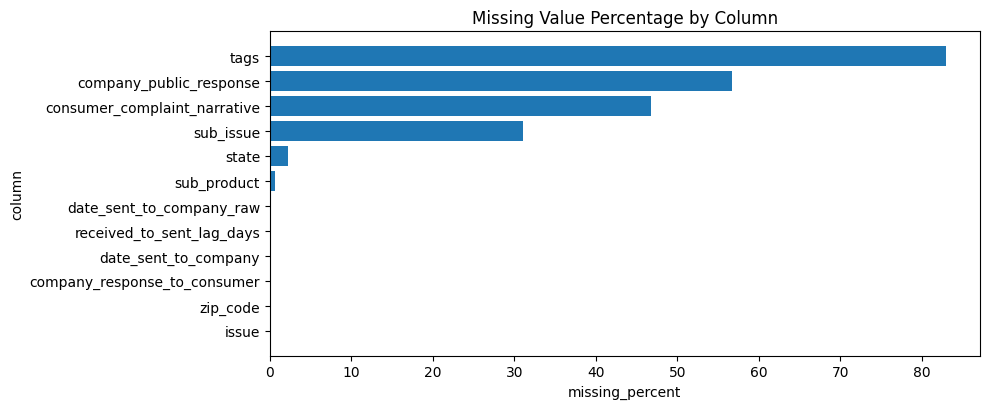

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_missing_value_percentage.png


In [11]:
# -------------------------------------------------------------------
# Missing value chart
# -------------------------------------------------------------------
missing_plot_table = column_summary[column_summary["missing_count"] > 0].copy()
missing_plot_table = missing_plot_table.sort_values("missing_percent", ascending=False)

if len(missing_plot_table) > 0:
    plot_horizontal_bar(
        missing_plot_table,
        label_col="column",
        value_col="missing_percent",
        title="Missing Value Percentage by Column",
        filename="eda_missing_value_percentage.png"
    )
else:
    print("No missing values found.")

## Step 6: Product Distribution

This directly supports RQ1, which examines whether product type is associated with timely response.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_product_counts.csv


,product,count,percent
0,Checking or savings account,333982,25.91
1,Mortgage,221283,17.17
2,Credit card or prepaid card,206357,16.01
3,Credit card,194996,15.13
4,"Money transfer, virtual currency, or money ser...",164638,12.77
5,Vehicle loan or lease,85430,6.63
6,"Payday loan, title loan, or personal loan",30622,2.38
7,"Payday loan, title loan, personal loan, or adv...",24745,1.92
8,Prepaid card,15540,1.21
9,Bank account or service,6955,0.54


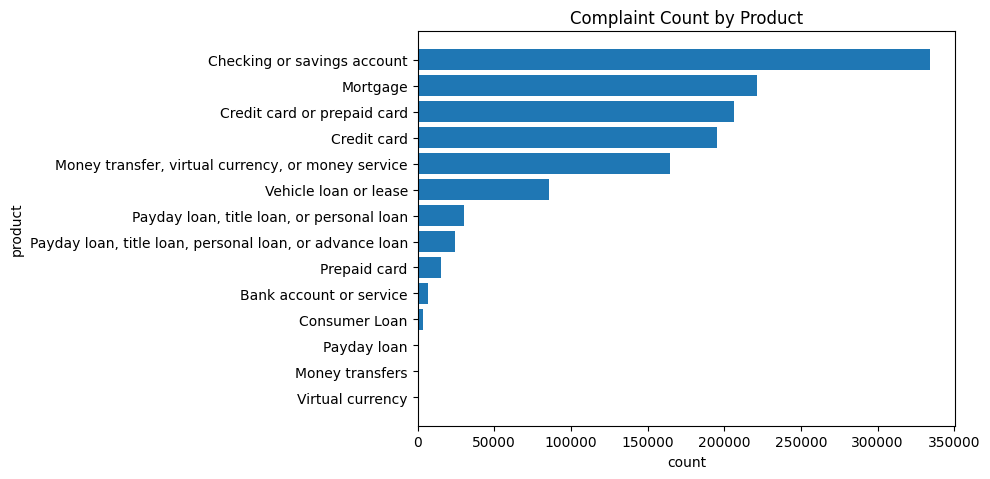

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_product_counts.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_product_counts.png')

In [12]:
# -------------------------------------------------------------------
# Product counts
# -------------------------------------------------------------------
product_counts = count_percent_table(df, "product")
save_table(product_counts, "eda_product_counts.csv")

display(product_counts)

plot_horizontal_bar(
    product_counts,
    label_col="product",
    value_col="count",
    title="Complaint Count by Product",
    filename="eda_product_counts.png"
)

## Step 7: Issue and Sub-Issue Distribution

Issue categories are important because RQ2 tests whether complaint issue categories significantly predict company response outcomes.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_issue_counts.csv


,issue,count,percent
0,Managing an account,195351,15.15
1,Trouble during payment process,101570,7.88
2,Problem with a purchase shown on your statement,90135,6.99
3,Other transaction problem,67507,5.24
4,Struggling to pay mortgage,56599,4.39
5,Incorrect information on your report,52718,4.09
6,Getting a credit card,46847,3.63
7,Closing an account,42856,3.32
8,"Other features, terms, or problems",40355,3.13
9,Fraud or scam,39213,3.04


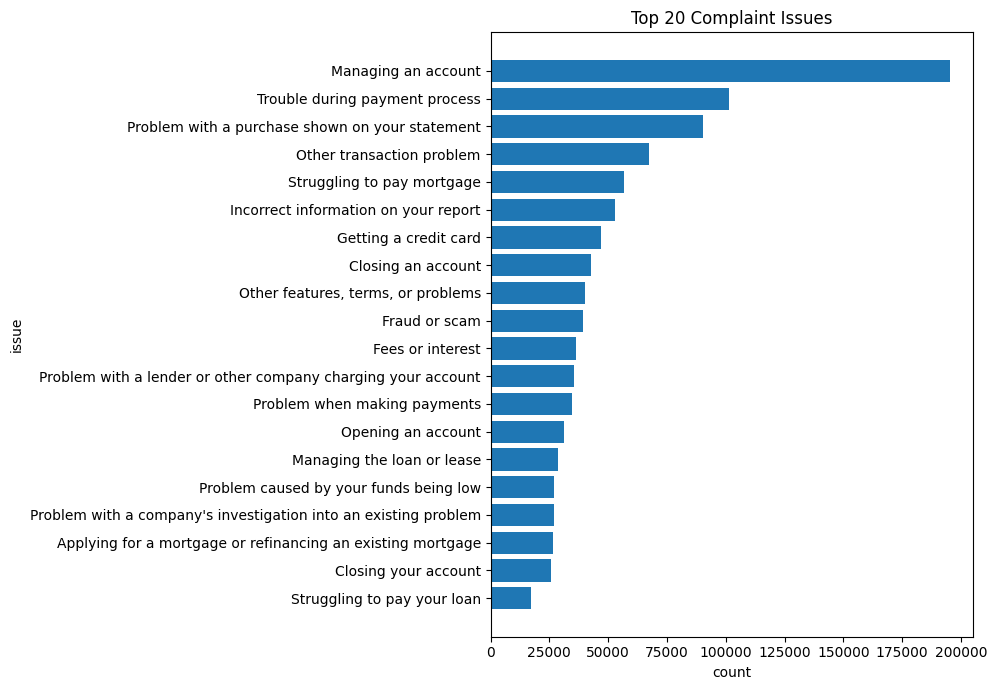

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_top_20_issues.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_top_20_issues.png')

In [13]:
# -------------------------------------------------------------------
# Top issues
# -------------------------------------------------------------------
issue_counts = count_percent_table(df, "issue")
save_table(issue_counts, "eda_issue_counts.csv")

display(issue_counts.head(30))

plot_horizontal_bar(
    issue_counts.head(20),
    label_col="issue",
    value_col="count",
    title="Top 20 Complaint Issues",
    filename="eda_top_20_issues.png"
)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_sub_issue_counts.csv


,sub_issue,count,percent
0,NaN,400657,31.08
1,Deposits and withdrawals,71039,5.51
2,Credit card company isn't resolving a dispute ...,63340,4.91
3,Problem using a debit or ATM card,38479,2.99
4,Company closed your account,38343,2.97
5,Account status incorrect,31554,2.45
6,Transaction was not authorized,28997,2.25
7,Was not notified of investigation status or re...,24609,1.91
8,Card was charged for something you did not pur...,24223,1.88
9,Problem during payment process,23320,1.81


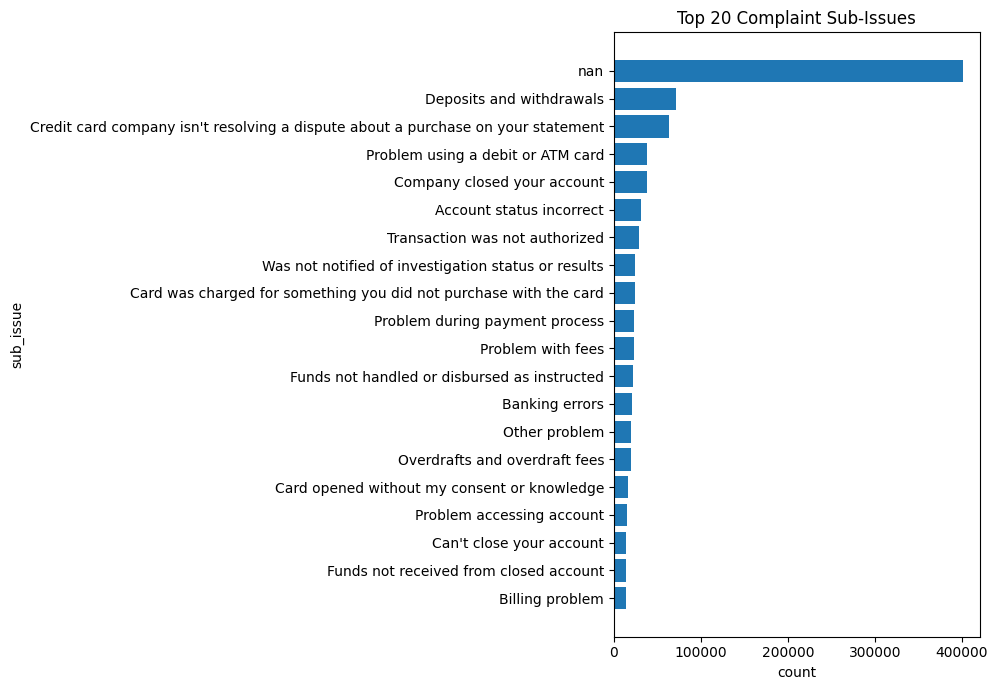

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_top_20_sub_issues.png


In [14]:
# -------------------------------------------------------------------
# Top sub-issues if available
# -------------------------------------------------------------------
if "sub_issue" in df.columns:
    sub_issue_counts = count_percent_table(df, "sub_issue")
    save_table(sub_issue_counts, "eda_sub_issue_counts.csv")

    display(sub_issue_counts.head(30))

    plot_horizontal_bar(
        sub_issue_counts.head(20),
        label_col="sub_issue",
        value_col="count",
        title="Top 20 Complaint Sub-Issues",
        filename="eda_top_20_sub_issues.png"
    )
else:
    print("sub_issue column not available.")

In [15]:
# -------------------------------------------------------------------
# Bivariate Analysis: Issue and Sub-Issue Distribution
# -------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Choose dataframe
eda_df = df.copy()

# Check required columns
required_cols = ["issue", "sub_issue"]

missing_cols = [col for col in required_cols if col not in eda_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Clean missing values for analysis
issue_subissue_df = eda_df[["issue", "sub_issue"]].copy()

issue_subissue_df["issue"] = issue_subissue_df["issue"].fillna("Missing issue")
issue_subissue_df["sub_issue"] = issue_subissue_df["sub_issue"].fillna("Missing sub-issue")

print("Total records used:", len(issue_subissue_df))
print("Unique issues:", issue_subissue_df["issue"].nunique())
print("Unique sub-issues:", issue_subissue_df["sub_issue"].nunique())

Total records used: 1289027
Unique issues: 142
Unique sub-issues: 166


### Issue and Sub-Issue Count Table

In [16]:
# -------------------------------------------------------------------
# Issue and Sub-Issue count distribution
# -------------------------------------------------------------------

issue_subissue_counts = (
    issue_subissue_df
    .groupby(["issue", "sub_issue"])
    .size()
    .reset_index(name="count")
    .sort_values(["issue", "count"], ascending=[True, False])
)

issue_subissue_counts["percent_of_total"] = (
    issue_subissue_counts["count"] / issue_subissue_counts["count"].sum() * 100
).round(2)

display(issue_subissue_counts.head(50))

# Save output
issue_subissue_counts.to_csv(
    OUTPUT_TABLES / "bivariate_issue_subissue_counts.csv",
    index=False
)

print("Saved: bivariate_issue_subissue_counts.csv")

,issue,sub_issue,count,percent_of_total
0,APR or interest rate,Missing sub-issue,250,0.02
1,"Account opening, closing, or management",Missing sub-issue,3271,0.25
2,Account terms and changes,Missing sub-issue,9,0.00
3,Adding money,Missing sub-issue,13,0.00
5,Advertising,Confusing or misleading advertising about the ...,373,0.03
4,Advertising,Changes in terms from what was offered or adve...,171,0.01
6,Advertising and marketing,Missing sub-issue,202,0.02
8,"Advertising and marketing, including promotion...",Didn't receive advertised or promotional terms,9436,0.73
7,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,6895,0.53
9,"Advertising, marketing or disclosures",Missing sub-issue,8,0.00


Saved: bivariate_issue_subissue_counts.csv


### Top Sub-Issues Within Each Issue

In [17]:
# -------------------------------------------------------------------
# Top sub-issues within each issue
# -------------------------------------------------------------------

top_n_subissues = 5

top_subissues_by_issue = (
    issue_subissue_counts
    .groupby("issue", group_keys=False)
    .head(top_n_subissues)
    .copy()
)

# Add percentage within each issue
issue_totals = (
    issue_subissue_df
    .groupby("issue")
    .size()
    .reset_index(name="issue_total")
)

top_subissues_by_issue = top_subissues_by_issue.merge(
    issue_totals,
    on="issue",
    how="left"
)

top_subissues_by_issue["percent_within_issue"] = (
    top_subissues_by_issue["count"] / top_subissues_by_issue["issue_total"] * 100
).round(2)

display(top_subissues_by_issue.head(100))

# Save output
top_subissues_by_issue.to_csv(
    OUTPUT_TABLES / "top_subissues_by_issue.csv",
    index=False
)

print("Saved: top_subissues_by_issue.csv")

,issue,sub_issue,count,percent_of_total,issue_total,percent_within_issue
0,APR or interest rate,Missing sub-issue,250,0.02,250,100.00
1,"Account opening, closing, or management",Missing sub-issue,3271,0.25,3271,100.00
2,Account terms and changes,Missing sub-issue,9,0.00,9,100.00
3,Adding money,Missing sub-issue,13,0.00,13,100.00
4,Advertising,Confusing or misleading advertising about the ...,373,0.03,544,68.57
5,Advertising,Changes in terms from what was offered or adve...,171,0.01,544,31.43
6,Advertising and marketing,Missing sub-issue,202,0.02,202,100.00
7,"Advertising and marketing, including promotion...",Didn't receive advertised or promotional terms,9436,0.73,16331,57.78
8,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,6895,0.53,16331,42.22
9,"Advertising, marketing or disclosures",Missing sub-issue,8,0.00,8,100.00


Saved: top_subissues_by_issue.csv


### Pivot Table: Issues × Sub-Issues

In [18]:
# -------------------------------------------------------------------
# Pivot table: Issue by Sub-Issue
# -------------------------------------------------------------------

issue_subissue_pivot = pd.crosstab(
    issue_subissue_df["issue"],
    issue_subissue_df["sub_issue"]
)

display(issue_subissue_pivot.head())

# Save full pivot
issue_subissue_pivot.to_csv(
    OUTPUT_TABLES / "pivot_issue_by_subissue_counts.csv"
)

print("Saved: pivot_issue_by_subissue_counts.csv")
print("Pivot shape:", issue_subissue_pivot.shape)

sub_issue,Account information incorrect,Account opened as a result of fraud,Account opened without my consent or knowledge,Account reinstatement or redemption after repossession,Account sold or transferred to another company,Account status incorrect,Add-on products and services,"An existing modification, forbearance plan, short sale, or other loss mitigation relief",Application denials,Application denied,"Applying for or obtaining a modification, forbearance plan, short sale, or deed-in-lieu",Banking errors,Billing dispute for services,Billing problem,Bounced checks or returned payments,Can't close your account,Can't stop withdrawals from your account,Can't use card to make purchases,Card company isn't resolving a dispute about a purchase or transfer,Card opened as result of identity theft or fraud,Card opened without my consent or knowledge,Card was charged for something you did not purchase with the card,Cashing a check,Changes in loan terms during or after closing,Changes in loan terms during the application process,Changes in terms from what was offered or advertised,Changes in terms mid-deal or after closing,Charged for a purchase or transfer you did not make with the card,Charged too much interest,Closing disclosure or other related disclosures,Company closed your account,Company communicating payment assistance or payment extension options,Company explaining amount owed,Confusing or misleading advertising,Confusing or misleading advertising about the card,Confusing or misleading advertising about the credit card,Confusing or misleading advertising or marketing,Confusing or missing disclosures,Credit card company forcing arbitration,Credit card company isn't resolving a dispute about a purchase on your statement,Credit card company won't increase or decrease your credit limit,Credit card company won't work with you while you're going through financial hardship,Credit denial,Credit inquiries on your report that you don't recognize,Credit monitoring or identity theft protection services,Damage caused or loss of personal items in vehicle during the actual repossession,Deficiency balance after repossession,Delay in processing application,Delays in the application process,Delays with the closing process,...,Problem while selling or giving up the vehicle,Problem with a check written from your prepaid card account,Problem with a credit reporting company's investigation into an existing problem,Problem with a trade-in,Problem with additional add-on products or services purchased with the loan,Problem with additional products or services purchased with the loan,Problem with balance transfer,Problem with cash advances,Problem with convenience check,Problem with customer service,Problem with direct deposit,Problem with fees,Problem with fees charged,Problem with fees or penalties,Problem with fraud alerts or security freezes,Problem with paying off the loan,Problem with personal statement of dispute,Problem with product or service terms changing,Problem with renewal,Problem with rewards from credit card,Problem with signing the paperwork,Problem with the interest rate,Public record information inaccurate,Received unsolicited financial product or insurance offers after opting out,Received unwanted marketing or advertising,Report provided to employer without your written authorization,Reporting company used your report improperly,Sent card you never applied for,Setting up an escrow account for taxes and insurance,Termination fees or other problem when ending the lease early,Their investigation did not fix an error on your report,Transaction was not authorized,Trouble closing card,Trouble getting a working replacement card,Trouble getting information about the card,"Trouble getting, activating, or registering a card",Trouble using the card to pay a bill,Trouble using the card to send money to another person,Trouble using the card to spend money in a store or online,"Trying to communicate with the company to fix an issue related to mod

Saved: pivot_issue_by_subissue_counts.csv
Pivot shape: (142, 166)


## Step 8: Submission Channel Distribution

Submission channel may influence response timeliness because some channels may be more structured, faster, or easier to process than others.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_submitted_via_counts.csv


,submitted_via,count,percent
0,Web,1057743,82.06
1,Referral,115982,9.00
2,Phone,90440,7.02
3,Postal mail,21424,1.66
4,Fax,3406,0.26
5,Email,32,0.00


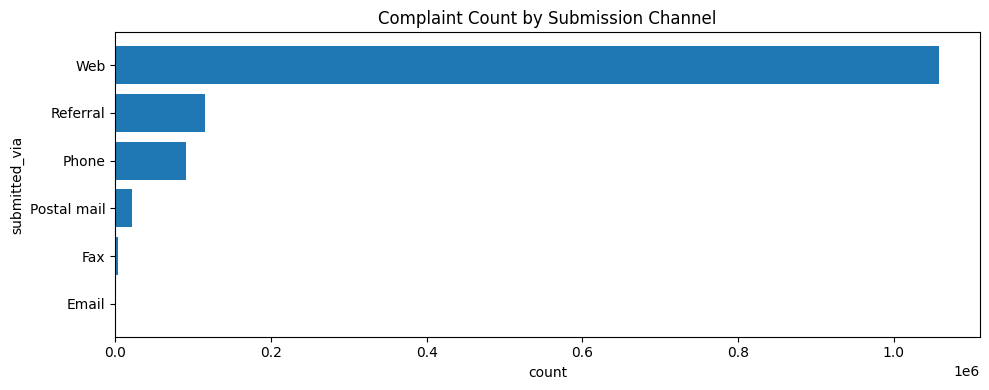

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_submission_channel_counts.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_submission_channel_counts.png')

In [19]:
# -------------------------------------------------------------------
# Submission channel counts
# -------------------------------------------------------------------
submitted_via_counts = count_percent_table(df, "submitted_via")
save_table(submitted_via_counts, "eda_submitted_via_counts.csv")

display(submitted_via_counts)

plot_horizontal_bar(
    submitted_via_counts,
    label_col="submitted_via",
    value_col="count",
    title="Complaint Count by Submission Channel",
    filename="eda_submission_channel_counts.png"
)

## Step 9: Target Variable Review — Timely Response

`timely_response` is the main binary target for the first predictive model. This section checks whether the target is balanced or imbalanced.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_timely_response_counts.csv


,timely_response,count,percent
0,Yes,1270902,98.59
1,No,18125,1.41


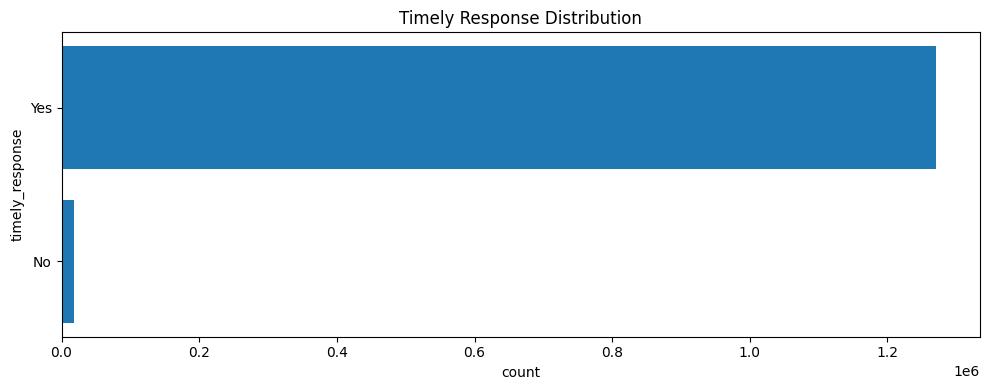

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_timely_response_distribution.png
Majority class share: 98.59%
Observation: The timely response target appears highly imbalanced.


In [20]:
# -------------------------------------------------------------------
# Timely response distribution
# -------------------------------------------------------------------
timely_response_counts = count_percent_table(df, "timely_response")
save_table(timely_response_counts, "eda_timely_response_counts.csv")

display(timely_response_counts)

plot_horizontal_bar(
    timely_response_counts,
    label_col="timely_response",
    value_col="count",
    title="Timely Response Distribution",
    filename="eda_timely_response_distribution.png"
)

majority_share = timely_response_counts["percent"].max()
print(f"Majority class share: {majority_share}%")

if majority_share >= 90:
    print("Observation: The timely response target appears highly imbalanced.")
elif majority_share >= 75:
    print("Observation: The timely response target appears moderately imbalanced.")
else:
    print("Observation: The timely response target appears reasonably balanced.")

## Step 10: Target Variable Review — Company Response Outcome

`company_response_to_consumer` can be used as a multi-class target or collapsed into simpler categories. This section checks how response outcomes are distributed.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_company_response_counts.csv


,company_response_to_consumer,count,percent
0,Closed with explanation,1038396,80.56
1,Closed with monetary relief,138939,10.78
2,Closed with non-monetary relief,108765,8.44
3,Untimely response,2445,0.19
4,Closed,399,0.03
5,NaN,61,0.00
6,In progress,22,0.00


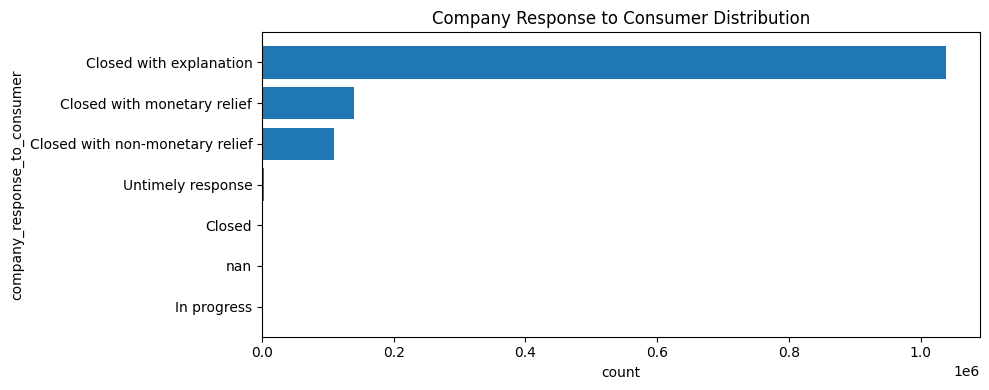

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_company_response_distribution.png
Majority response category share: 80.56%
Observation: Company response outcome may be imbalanced and may require class-balancing methods during modeling.


In [21]:
# -------------------------------------------------------------------
# Company response distribution
# -------------------------------------------------------------------
company_response_counts = count_percent_table(df, "company_response_to_consumer")
save_table(company_response_counts, "eda_company_response_counts.csv")

display(company_response_counts)

plot_horizontal_bar(
    company_response_counts,
    label_col="company_response_to_consumer",
    value_col="count",
    title="Company Response to Consumer Distribution",
    filename="eda_company_response_distribution.png"
)

majority_share = company_response_counts["percent"].max()
print(f"Majority response category share: {majority_share}%")

if majority_share >= 75:
    print("Observation: Company response outcome may be imbalanced and may require class-balancing methods during modeling.")
else:
    print("Observation: Company response outcome is not dominated by a single class.")

## Step 11: Narrative Availability

This supports RQ3. The study will compare structured-only models with structured-plus-narrative models. This section checks how many records have complaint narratives.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_narrative_availability_counts.csv


,has_narrative,count,percent,label
0,1,686744,53.28,Narrative available
1,0,602283,46.72,Narrative not available


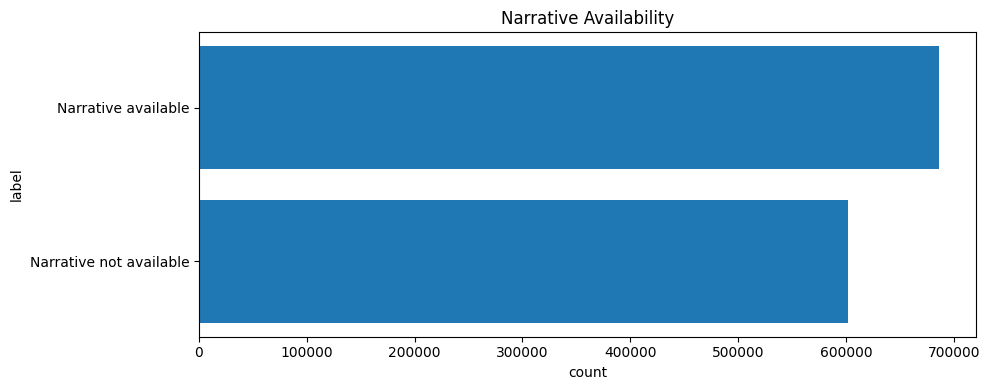

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_narrative_availability.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_narrative_availability.png')

In [22]:
# -------------------------------------------------------------------
# Narrative availability
# -------------------------------------------------------------------
if "has_narrative" not in df.columns:
    df["has_narrative"] = df["consumer_complaint_narrative"].notna().astype(int)

narrative_counts = count_percent_table(df, "has_narrative")
narrative_counts["label"] = narrative_counts["has_narrative"].map({
    1: "Narrative available",
    0: "Narrative not available"
})

save_table(narrative_counts, "eda_narrative_availability_counts.csv")

display(narrative_counts)

plot_horizontal_bar(
    narrative_counts,
    label_col="label",
    value_col="count",
    title="Narrative Availability",
    filename="eda_narrative_availability.png"
)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_narrative_length_summary.csv


,statistic,value
0,count,686744.000000
1,mean,1257.582715
2,std,1422.610056
3,min,4.000000
4,25%,504.000000
5,50%,852.000000
6,75%,1538.000000
7,max,32959.000000


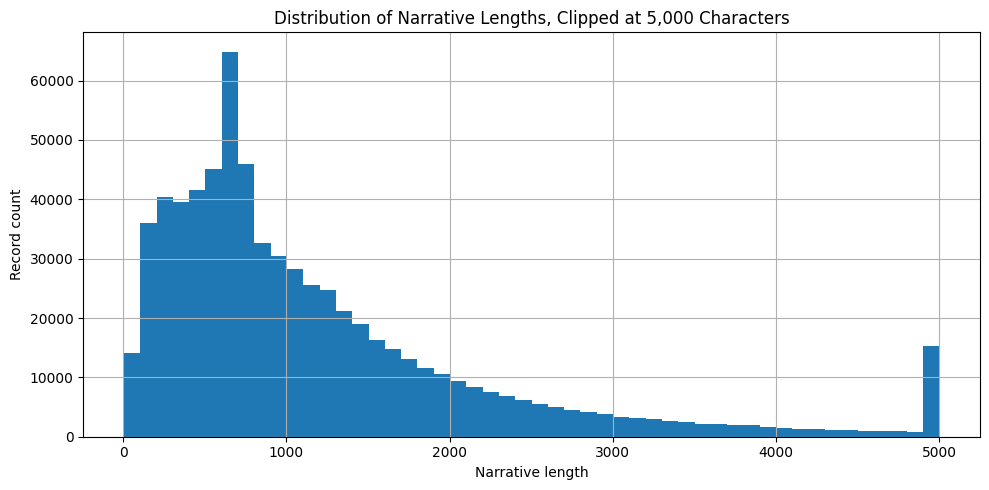

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_narrative_length_distribution.png


In [23]:
# -------------------------------------------------------------------
# Narrative length summary
# -------------------------------------------------------------------
if "narrative_length" not in df.columns:
    df["narrative_length"] = df["consumer_complaint_narrative"].fillna("").astype(str).str.len()

narrative_length_summary = df.loc[df["has_narrative"] == 1, "narrative_length"].describe().reset_index()
narrative_length_summary.columns = ["statistic", "value"]

save_table(narrative_length_summary, "eda_narrative_length_summary.csv")

display(narrative_length_summary)

plt.figure(figsize=(10, 5))
df.loc[df["has_narrative"] == 1, "narrative_length"].clip(upper=5000).hist(bins=50)
plt.title("Distribution of Narrative Lengths, Clipped at 5,000 Characters")
plt.xlabel("Narrative length")
plt.ylabel("Record count")
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "eda_narrative_length_distribution.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## Step 12: Time Trend Analysis

This section reviews complaint volume over time. Trends are useful for understanding whether complaint volume changed across years and whether any periods need special attention.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_yearly_complaint_counts.csv


,year_received,count,percent
0,2017,87630,6.80
1,2018,85688,6.65
2,2019,85144,6.61
3,2020,102245,7.93
4,2021,113975,8.84
5,2022,128683,9.98
6,2023,165960,12.87
7,2024,195722,15.18
8,2025,323980,25.13


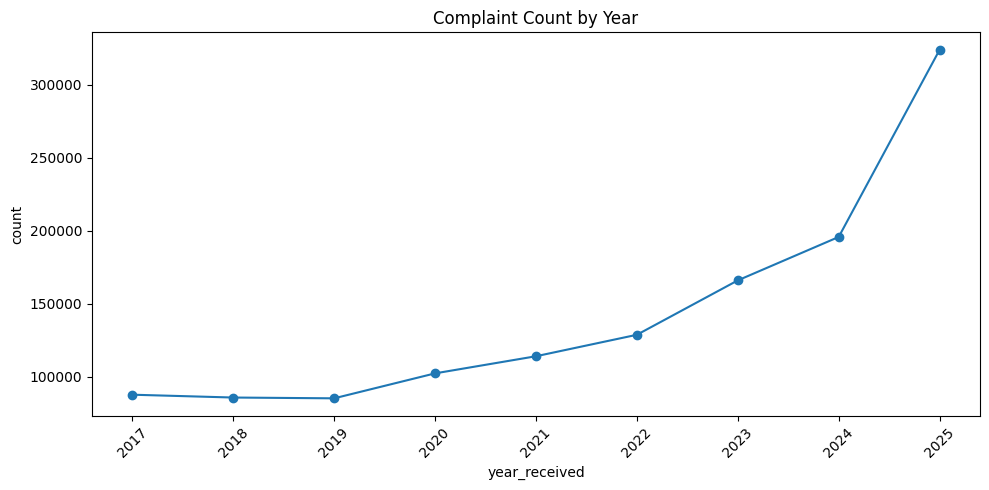

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_complaint_count_by_year.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_complaint_count_by_year.png')

In [24]:
# -------------------------------------------------------------------
# Complaint count by year
# -------------------------------------------------------------------
year_counts = df["year_received"].value_counts().sort_index().reset_index()
year_counts.columns = ["year_received", "count"]
year_counts["percent"] = (year_counts["count"] / year_counts["count"].sum() * 100).round(2)

save_table(year_counts, "eda_yearly_complaint_counts.csv")

display(year_counts)

plot_line(
    year_counts,
    x_col="year_received",
    y_col="count",
    title="Complaint Count by Year",
    filename="eda_complaint_count_by_year.png"
)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_monthly_complaint_counts.csv


,month_received,count
0,2017-01,8496
1,2017-02,7784
2,2017-03,8672
3,2017-04,7172
4,2017-05,6999


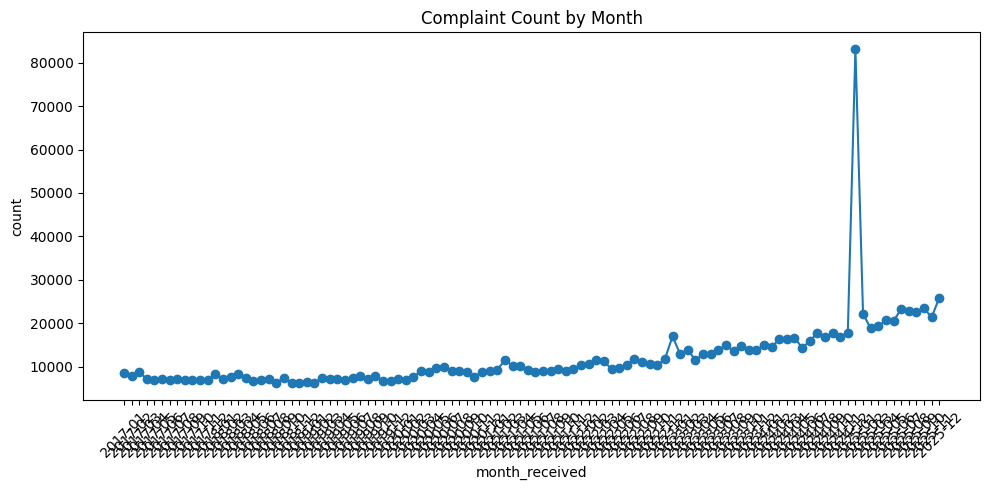

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_complaint_count_by_month.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_complaint_count_by_month.png')

In [25]:
# -------------------------------------------------------------------
# Complaint count by month
# -------------------------------------------------------------------
month_counts = df["month_received"].value_counts().sort_index().reset_index()
month_counts.columns = ["month_received", "count"]

save_table(month_counts, "eda_monthly_complaint_counts.csv")

display(month_counts.head())

plot_line(
    month_counts,
    x_col="month_received",
    y_col="count",
    title="Complaint Count by Month",
    filename="eda_complaint_count_by_month.png"
)

## Step 13: Product and Timely Response Cross-Tab

This directly supports RQ1 by showing timely-response rates by product before formal statistical testing.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_timely_response_by_product.csv


,product,total_records,timely_records,timely_rate,timely_rate_percent
1,Checking or savings account,333982,330627,0.989955,99.00
7,Mortgage,221283,218042,0.985354,98.54
4,Credit card or prepaid card,206357,203925,0.988215,98.82
3,Credit card,194996,194335,0.996610,99.66
5,"Money transfer, virtual currency, or money ser...",164638,162007,0.984019,98.40
12,Vehicle loan or lease,85430,83846,0.981459,98.15
9,"Payday loan, title loan, or personal loan",30622,29039,0.948305,94.83
10,"Payday loan, title loan, personal loan, or adv...",24745,23734,0.959143,95.91
11,Prepaid card,15540,14718,0.947104,94.71
0,Bank account or service,6955,6436,0.925377,92.54


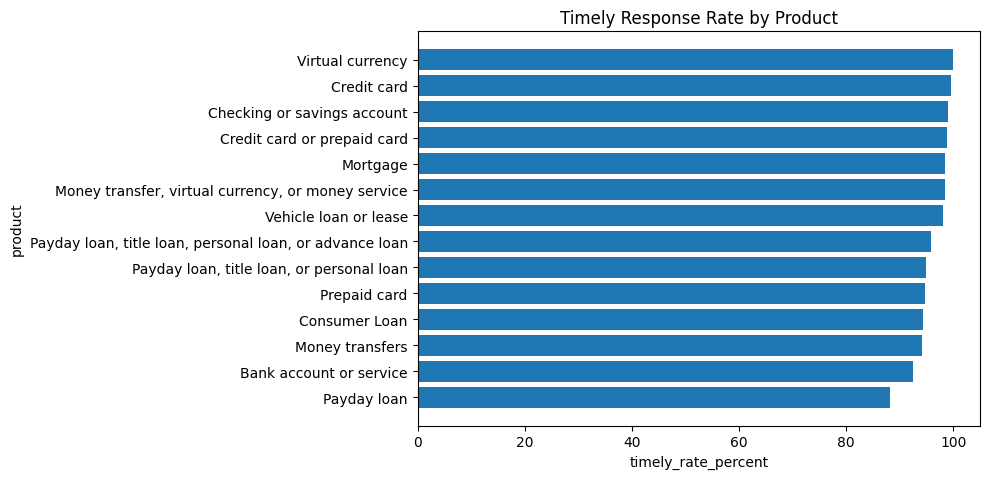

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_timely_response_rate_by_product.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_timely_response_rate_by_product.png')

In [26]:
# -------------------------------------------------------------------
# Timely response rate by product
# -------------------------------------------------------------------
if "timely_response_binary" not in df.columns:
    df["timely_response_binary"] = (
        df["timely_response"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map({"yes": 1, "no": 0})
    )

timely_by_product = (
    df
    .groupby("product", dropna=False)
    .agg(
        total_records=("timely_response_binary", "size"),
        timely_records=("timely_response_binary", "sum"),
        timely_rate=("timely_response_binary", "mean")
    )
    .reset_index()
)

timely_by_product["timely_rate_percent"] = (timely_by_product["timely_rate"] * 100).round(2)
timely_by_product = timely_by_product.sort_values("total_records", ascending=False)

save_table(timely_by_product, "eda_timely_response_by_product.csv")

display(timely_by_product)

plot_horizontal_bar(
    timely_by_product.sort_values("timely_rate_percent", ascending=False),
    label_col="product",
    value_col="timely_rate_percent",
    title="Timely Response Rate by Product",
    filename="eda_timely_response_rate_by_product.png"
)

## Step 14: Issue and Response Outcome Cross-Tab

This helps prepare for RQ2 by showing which issues are most associated with response outcomes. Formal testing will be done in Notebook 03.

In [27]:
# -------------------------------------------------------------------
# Issue by company response cross-tab
# -------------------------------------------------------------------
top_issues = issue_counts.head(15)["issue"].tolist()

issue_response_crosstab = pd.crosstab(
    df.loc[df["issue"].isin(top_issues), "issue"],
    df.loc[df["issue"].isin(top_issues), "company_response_to_consumer"],
    normalize="index"
).round(4) * 100

issue_response_crosstab = issue_response_crosstab.reset_index()

save_table(issue_response_crosstab, "eda_issue_response_crosstab_top_15.csv")

issue_response_crosstab

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_issue_response_crosstab_top_15.csv


company_response_to_consumer,issue,Closed,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
0,Closing an account,0.00,80.21,12.13,7.62,0.00,0.04
1,Fees or interest,0.00,60.48,34.90,4.56,0.02,0.04
2,Fraud or scam,0.00,89.34,7.37,2.89,0.00,0.40
3,Getting a credit card,0.00,68.58,2.08,29.26,0.00,0.08
4,Incorrect information on your report,0.00,68.73,1.36,29.75,0.00,0.15
5,Managing an account,0.00,79.74,15.34,4.87,0.00,0.05
6,Managing the loan or lease,0.18,89.35,4.73,5.35,0.00,0.38
7,Opening an account,0.00,78.45,11.25,10.25,0.00,0.05
8,"Other features, terms, or problems",0.00,71.76,14.58,13.61,0.00,0.05
9,Other transaction problem,0.00,95.96,2.93,1.02,0.00,0.08


## Step 15: Company and Geographic Review

This section supports RQ4. Company and state fields can be useful, but results must be interpreted carefully because the CFPB public dataset does not include company market share or customer base size.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_company_counts.csv


,company,count,percent
0,JPMORGAN CHASE & CO.,92441,7.17
1,WELLS FARGO & COMPANY,87155,6.76
2,"BANK OF AMERICA, NATIONAL ASSOCIATION",85088,6.60
3,CAPITAL ONE FINANCIAL CORPORATION,70529,5.47
4,"CITIBANK, N.A.",66000,5.12
5,"Block, Inc.",59072,4.58
6,SYNCHRONY FINANCIAL,33533,2.60
7,AMERICAN EXPRESS COMPANY,30731,2.38
8,"Paypal Holdings, Inc",28600,2.22
9,U.S. BANCORP,27497,2.13


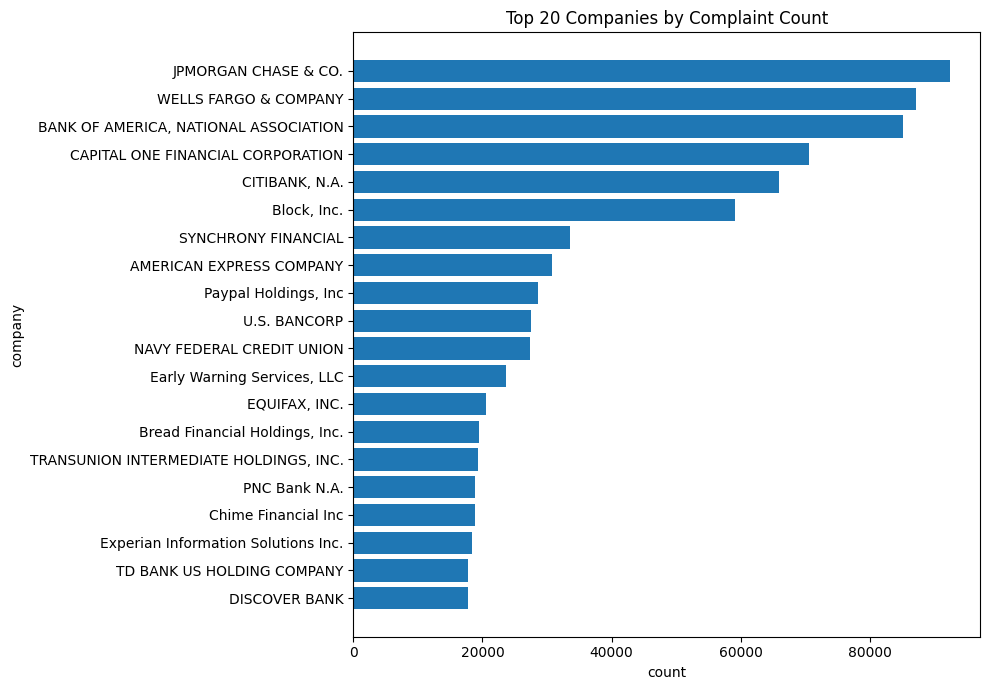

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_top_20_companies.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_top_20_companies.png')

In [28]:
# -------------------------------------------------------------------
# Top companies by complaint count
# -------------------------------------------------------------------
company_counts = count_percent_table(df, "company")
save_table(company_counts, "eda_company_counts.csv")

display(company_counts.head(30))

plot_horizontal_bar(
    company_counts.head(20),
    label_col="company",
    value_col="count",
    title="Top 20 Companies by Complaint Count",
    filename="eda_top_20_companies.png"
)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_state_counts.csv


,state,count,percent
0,CA,172756,13.40
1,FL,118868,9.22
2,TX,114626,8.89
3,NY,91474,7.10
4,GA,62588,4.86
5,IL,55818,4.33
6,PA,47376,3.68
7,NJ,46891,3.64
8,NC,38311,2.97
9,VA,38033,2.95


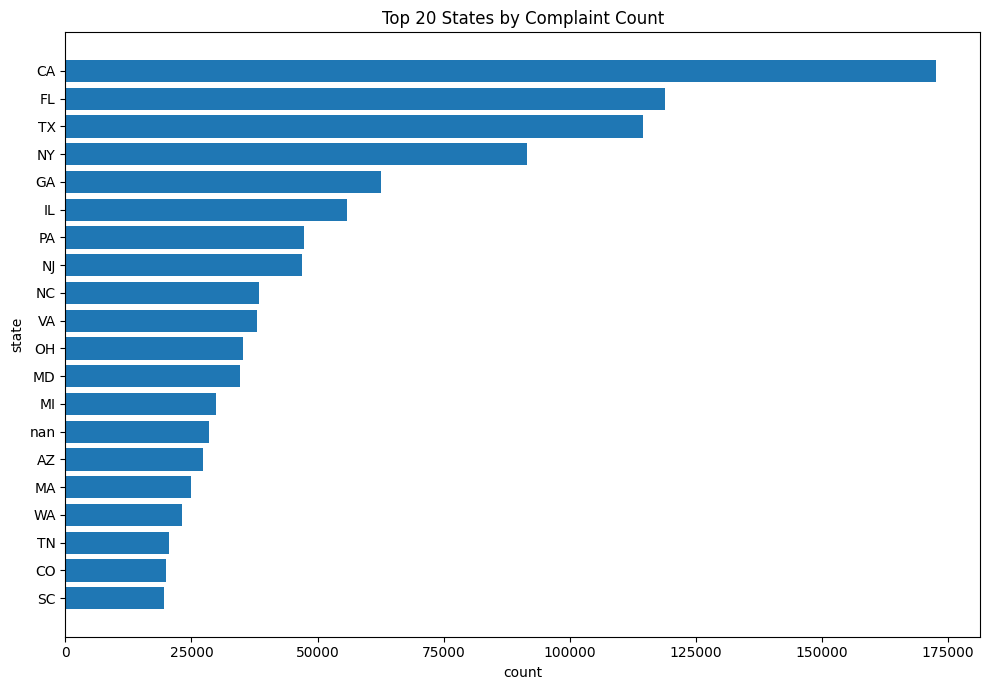

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_top_20_states.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_top_20_states.png')

In [29]:
# -------------------------------------------------------------------
# State distribution
# -------------------------------------------------------------------
state_counts = count_percent_table(df, "state")
save_table(state_counts, "eda_state_counts.csv")

display(state_counts.head(30))

plot_horizontal_bar(
    state_counts.head(20),
    label_col="state",
    value_col="count",
    title="Top 20 States by Complaint Count",
    filename="eda_top_20_states.png"
)

## Step 16: Process Lag Review

The field `received_to_sent_lag_days` is useful for process analysis. However, it should not be used as an intake-stage predictor unless it is known at the prediction point.

This is important for data leakage prevention.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_received_to_sent_lag_summary.csv


,statistic,value
0,count,1.289013e+06
1,mean,1.698161e+00
2,std,8.596410e+00
3,min,0.000000e+00
4,25%,0.000000e+00
5,50%,0.000000e+00
6,75%,0.000000e+00
7,max,1.874000e+03


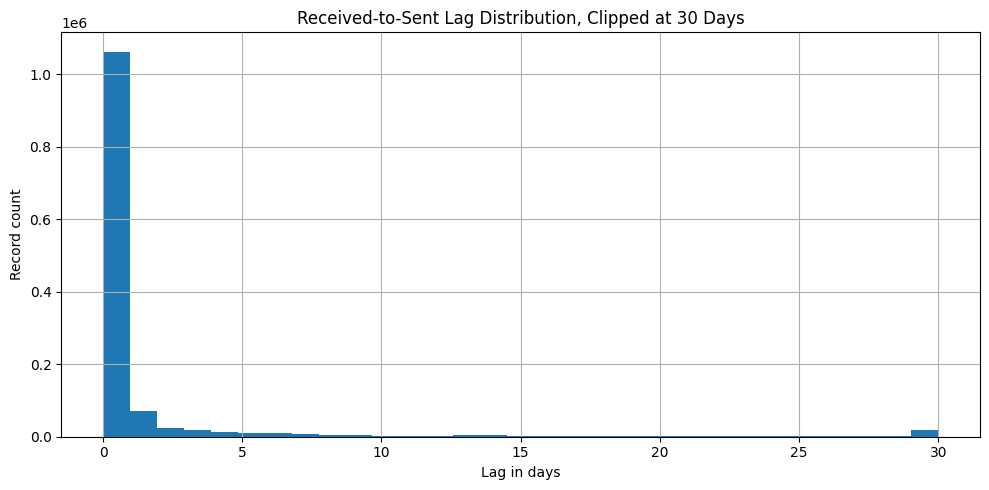

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_received_to_sent_lag_distribution.png


In [30]:
# -------------------------------------------------------------------
# Process lag summary
# -------------------------------------------------------------------
if "received_to_sent_lag_days" not in df.columns and {"date_received", "date_sent_to_company"}.issubset(df.columns):
    df["received_to_sent_lag_days"] = (df["date_sent_to_company"] - df["date_received"]).dt.days

if "received_to_sent_lag_days" in df.columns:
    lag_summary = df["received_to_sent_lag_days"].describe().reset_index()
    lag_summary.columns = ["statistic", "value"]
    save_table(lag_summary, "eda_received_to_sent_lag_summary.csv")

    display(lag_summary)

    plt.figure(figsize=(10, 5))
    df["received_to_sent_lag_days"].dropna().clip(lower=0, upper=30).hist(bins=31)
    plt.title("Received-to-Sent Lag Distribution, Clipped at 30 Days")
    plt.xlabel("Lag in days")
    plt.ylabel("Record count")
    plt.tight_layout()

    figure_path = OUTPUT_FIGURES / "eda_received_to_sent_lag_distribution.png"
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", figure_path)
else:
    print("received_to_sent_lag_days not available.")

## Step 17: Tags Review

The `tags` field may identify special consumer groups, such as older Americans or servicemembers. This field can be useful for descriptive analysis and ethical discussion, but it should be handled carefully in modeling.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_tags_counts.csv


,tags,count,percent
0,NaN,1069670,82.98
1,Servicemember,103844,8.06
2,Older American,89503,6.94
3,"Older American, Servicemember",26010,2.02


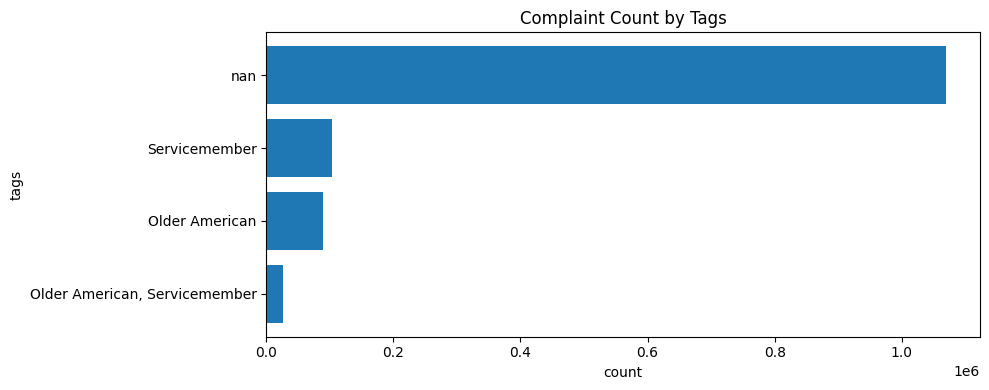

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_tags_counts.png


In [31]:
# -------------------------------------------------------------------
# Tags distribution
# -------------------------------------------------------------------
if "tags" in df.columns:
    tags_counts = count_percent_table(df, "tags")
    save_table(tags_counts, "eda_tags_counts.csv")

    display(tags_counts)

    plot_horizontal_bar(
        tags_counts.head(20),
        label_col="tags",
        value_col="count",
        title="Complaint Count by Tags",
        filename="eda_tags_counts.png"
    )
else:
    print("tags column not available.")

## Step 18: Extended Univariate Analysis

This section adds deeper one-variable profiling beyond simple counts. It summarizes numeric engineered fields, highlights category concentration, and identifies fields where a few values dominate the dataset.

These outputs are useful for the final report because they show whether the dataset is balanced, concentrated, sparse, or potentially biased toward certain complaint types, companies, channels, or geographies.


In [32]:
# -------------------------------------------------------------------
# Ensure key engineered fields exist for extended EDA
# -------------------------------------------------------------------

if "timely_response_binary" not in df.columns and "timely_response" in df.columns:
    df["timely_response_binary"] = (
        df["timely_response"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map({"yes": 1, "no": 0})
    )

if "has_narrative" not in df.columns and "consumer_complaint_narrative" in df.columns:
    df["has_narrative"] = df["consumer_complaint_narrative"].notna().astype(int)

if "narrative_length" not in df.columns and "consumer_complaint_narrative" in df.columns:
    df["narrative_length"] = (
        df["consumer_complaint_narrative"]
        .fillna("")
        .astype(str)
        .str.len()
    )

if "received_to_sent_lag_days" not in df.columns and {"date_received", "date_sent_to_company"}.issubset(df.columns):
    df["received_to_sent_lag_days"] = (
        df["date_sent_to_company"] - df["date_received"]
    ).dt.days

print("Extended EDA fields checked.")
print("Current dataset shape:", df.shape)


Extended EDA fields checked.
Current dataset shape: (1289027, 25)


In [33]:
# -------------------------------------------------------------------
# Numeric univariate summary
# -------------------------------------------------------------------

numeric_candidate_columns = [
    "year_received",
    "timely_response_binary",
    "has_narrative",
    "narrative_length",
    "received_to_sent_lag_days"
]

numeric_columns = [
    col for col in numeric_candidate_columns
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

if numeric_columns:
    numeric_univariate_summary = (
        df[numeric_columns]
        .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
        .T
        .reset_index()
        .rename(columns={"index": "field"})
    )

    numeric_univariate_summary["missing_count"] = [
        df[col].isna().sum() for col in numeric_univariate_summary["field"]
    ]
    numeric_univariate_summary["missing_percent"] = [
        round(df[col].isna().mean() * 100, 2) for col in numeric_univariate_summary["field"]
    ]

    save_table(numeric_univariate_summary, "eda_numeric_univariate_summary.csv")
    display(numeric_univariate_summary)
else:
    print("No numeric columns available for extended univariate summary.")


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_numeric_univariate_summary.csv


,field,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_count,missing_percent
0,year_received,1289027.0,2022.135408,2.596750,2017.0,2017.0,2017.0,2020.0,2023.0,2025.0,2025.0,2025.0,2025.0,0,0.0
1,timely_response_binary,1289027.0,0.985939,0.117742,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,0.0
2,has_narrative,1289027.0,0.532762,0.498926,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0,0.0
3,narrative_length,1289027.0,669.991695,1213.216298,0.0,0.0,0.0,0.0,183.0,918.0,2662.0,5250.0,32959.0,0,0.0
4,received_to_sent_lag_days,1289013.0,1.698161,8.596410,0.0,0.0,0.0,0.0,0.0,0.0,9.0,36.0,1874.0,14,0.0


In [34]:
# -------------------------------------------------------------------
# Categorical concentration summary
# -------------------------------------------------------------------
# The Herfindahl-Hirschman Index (HHI) is used here as a simple
# concentration indicator. Higher values mean a few categories dominate.

categorical_candidate_columns = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company",
    "state",
    "zip_code",
    "tags",
    "submitted_via",
    "company_response_to_consumer",
    "timely_response"
]

categorical_columns = [col for col in categorical_candidate_columns if col in df.columns]

concentration_rows = []

for col in categorical_columns:
    counts = df[col].fillna("Missing").astype(str).value_counts(dropna=False)
    total = counts.sum()

    proportions = counts / total
    hhi = float((proportions ** 2).sum())

    concentration_rows.append({
        "field": col,
        "total_records": int(total),
        "missing_count": int(df[col].isna().sum()),
        "missing_percent": round(df[col].isna().mean() * 100, 2),
        "unique_values": int(df[col].nunique(dropna=True)),
        "top_value": counts.index[0],
        "top_value_count": int(counts.iloc[0]),
        "top_value_percent": round(counts.iloc[0] / total * 100, 2),
        "top_5_percent": round(counts.head(5).sum() / total * 100, 2),
        "hhi_concentration": round(hhi, 4)
    })

categorical_concentration_summary = (
    pd.DataFrame(concentration_rows)
    .sort_values("hhi_concentration", ascending=False)
)

save_table(categorical_concentration_summary, "eda_categorical_concentration_summary.csv")
display(categorical_concentration_summary)


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_categorical_concentration_summary.csv


,field,total_records,missing_count,missing_percent,unique_values,top_value,top_value_count,top_value_percent,top_5_percent,hhi_concentration
10,timely_response,1289027,0,0.00,2,Yes,1270902,98.59,100.00,0.9723
7,tags,1289027,1069670,82.98,3,Missing,1069670,82.98,100.00,0.7003
8,submitted_via,1289027,0,0.00,6,Web,1057743,82.06,100.00,0.6866
9,company_response_to_consumer,1289027,61,0.00,6,Closed with explanation,1038396,80.56,99.99,0.6677
0,product,1289027,0,0.00,14,Checking or savings account,333982,25.91,86.98,0.1669
1,sub_product,1289027,7762,0.60,58,General-purpose credit card or charge card,326802,25.35,68.23,0.1323
3,sub_issue,1289027,400657,31.08,165,Missing,400657,31.08,47.47,0.1093
5,state,1289027,28399,2.20,63,CA,172756,13.40,43.47,0.0540
2,issue,1289027,5,0.00,141,Managing an account,195351,15.15,39.65,0.0515
4,company,1289027,0,0.00,4617,JPMORGAN CHASE & CO.,92441,7.17,31.13,0.0280


## Step 19: Extended Bivariate Analysis

This section compares important fields against the main business outcomes. It focuses on response timeliness, narrative availability, relief-based responses, and process timing.

Small groups can produce misleading rates, so minimum record thresholds are used before ranking categories.


In [35]:
# -------------------------------------------------------------------
# Helper functions for bivariate rate tables
# -------------------------------------------------------------------

def grouped_binary_rate(dataframe, group_col, target_col, min_records=500, top_n=30):
    if group_col not in dataframe.columns:
        print(f"Column not available: {group_col}")
        return pd.DataFrame()

    if target_col not in dataframe.columns:
        print(f"Target not available: {target_col}")
        return pd.DataFrame()

    temp = dataframe[[group_col, target_col]].copy()
    temp[group_col] = temp[group_col].fillna("Missing").astype(str)
    temp = temp.dropna(subset=[target_col])

    overall_rate = temp[target_col].mean()

    table = (
        temp
        .groupby(group_col, dropna=False)
        .agg(
            total_records=(target_col, "size"),
            positive_records=(target_col, "sum"),
            positive_rate=(target_col, "mean")
        )
        .reset_index()
    )

    table["positive_rate_percent"] = (table["positive_rate"] * 100).round(2)
    table["overall_rate_percent"] = round(overall_rate * 100, 2)
    table["rate_difference_vs_overall_pp"] = (
        table["positive_rate_percent"] - table["overall_rate_percent"]
    ).round(2)

    table = table[table["total_records"] >= min_records].copy()
    table = table.sort_values(
        ["rate_difference_vs_overall_pp", "total_records"],
        ascending=[False, False]
    )

    if top_n is not None:
        table = table.head(top_n)

    return table


def grouped_numeric_summary(dataframe, group_col, value_col, min_records=500, top_n=30):
    if group_col not in dataframe.columns or value_col not in dataframe.columns:
        return pd.DataFrame()

    temp = dataframe[[group_col, value_col]].copy()
    temp[group_col] = temp[group_col].fillna("Missing").astype(str)
    temp = temp.dropna(subset=[value_col])

    table = (
        temp
        .groupby(group_col)
        .agg(
            total_records=(value_col, "size"),
            mean_value=(value_col, "mean"),
            median_value=(value_col, "median"),
            p75_value=(value_col, lambda x: x.quantile(0.75)),
            p90_value=(value_col, lambda x: x.quantile(0.90))
        )
        .reset_index()
    )

    table = table[table["total_records"] >= min_records].copy()
    for col in ["mean_value", "median_value", "p75_value", "p90_value"]:
        table[col] = table[col].round(2)

    table = table.sort_values(["mean_value", "total_records"], ascending=[False, False])

    if top_n is not None:
        table = table.head(top_n)

    return table


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_timely_response_rate_by_product.csv
Timely-response rate by product


,product,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
3,Credit card,194996,194335,0.996610,99.66,98.59,1.07
1,Checking or savings account,333982,330627,0.989955,99.00,98.59,0.41
4,Credit card or prepaid card,206357,203925,0.988215,98.82,98.59,0.23
7,Mortgage,221283,218042,0.985354,98.54,98.59,-0.05
5,"Money transfer, virtual currency, or money ser...",164638,162007,0.984019,98.40,98.59,-0.19
12,Vehicle loan or lease,85430,83846,0.981459,98.15,98.59,-0.44
10,"Payday loan, title loan, personal loan, or adv...",24745,23734,0.959143,95.91,98.59,-2.68
9,"Payday loan, title loan, or personal loan",30622,29039,0.948305,94.83,98.59,-3.76
11,Prepaid card,15540,14718,0.947104,94.71,98.59,-3.88
2,Consumer Loan,3543,3341,0.942986,94.30,98.59,-4.29


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_timely_response_rate_by_submitted_via.csv
Timely-response rate by submitted_via


,submitted_via,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
4,Referral,115982,114618,0.988240,98.82,98.59,0.23
3,Postal mail,21424,21132,0.986370,98.64,98.59,0.05
5,Web,1057743,1042951,0.986016,98.60,98.59,0.01
2,Phone,90440,88832,0.982220,98.22,98.59,-0.37
1,Fax,3406,3337,0.979742,97.97,98.59,-0.62


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_timely_response_rate_by_issue.csv
Timely-response rate by issue


...

,company,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
4291,U.S. BANCORP,27497,27497,1.000000,100.00,98.59,1.41
2879,NAVY FEDERAL CREDIT UNION,27306,27305,0.999963,100.00,98.59,1.41
3184,PNC Bank N.A.,18915,18915,1.000000,100.00,98.59,1.41
1239,DISCOVER BANK,17734,17734,1.000000,100.00,98.59,1.41
2248,JPMORGAN CHASE & CO.,92441,92433,0.999913,99.99,98.59,1.40
1397,"EQUIFAX, INC.",20527,20524,0.999854,99.99,98.59,1.40
654,"Bread Financial Holdings, Inc.",19421,19419,0.999897,99.99,98.59,1.40
4111,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",19292,19291,0.999948,99.99,98.59,1.40
1508,Experian Information Solutions Inc.,18339,18338,0.999945,99.99,98.59,1.40
4072,TD BANK US HOLDING COMPANY,17843,17842,0.999944,99.99,98.59,1.40


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_timely_response_rate_by_state.csv
Timely-response rate by state


,state,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
62,WV,3965,3932,0.991677,99.17,98.59,0.58
27,ME,2713,2690,0.991522,99.15,98.59,0.56
43,NY,91474,90566,0.990074,99.01,98.59,0.42
20,IL,55818,55217,0.989233,98.92,98.59,0.33
44,OH,35280,34866,0.988265,98.83,98.59,0.24
47,PA,47376,46817,0.988201,98.82,98.59,0.23
29,MI,29777,29427,0.988246,98.82,98.59,0.23
24,LA,15632,15447,0.988165,98.82,98.59,0.23
12,DE,6517,6440,0.988185,98.82,98.59,0.23
59,VT,1521,1503,0.988166,98.82,98.59,0.23


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_timely_response_rate_by_tags.csv
Timely-response rate by tags


,tags,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
2,"Older American, Servicemember",26010,25666,0.986774,98.68,98.59,0.09
0,Missing,1069670,1054640,0.985949,98.59,98.59,0.00
1,Older American,89503,88243,0.985922,98.59,98.59,0.00
3,Servicemember,103844,102353,0.985642,98.56,98.59,-0.03


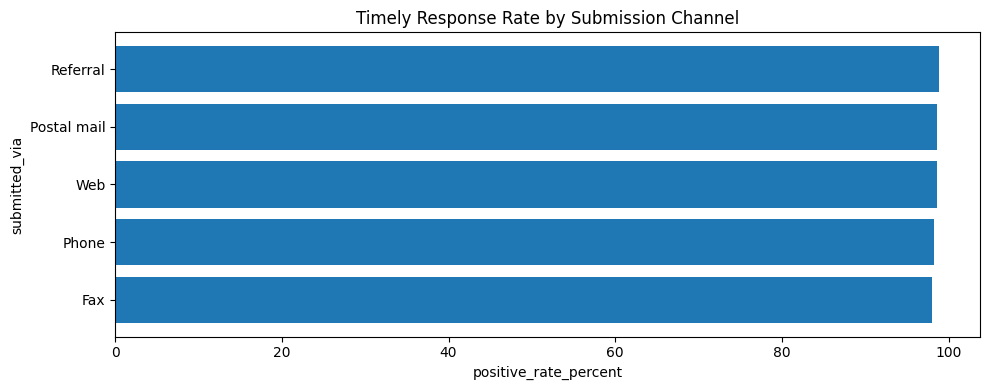

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_timely_response_rate_by_submitted_via.png


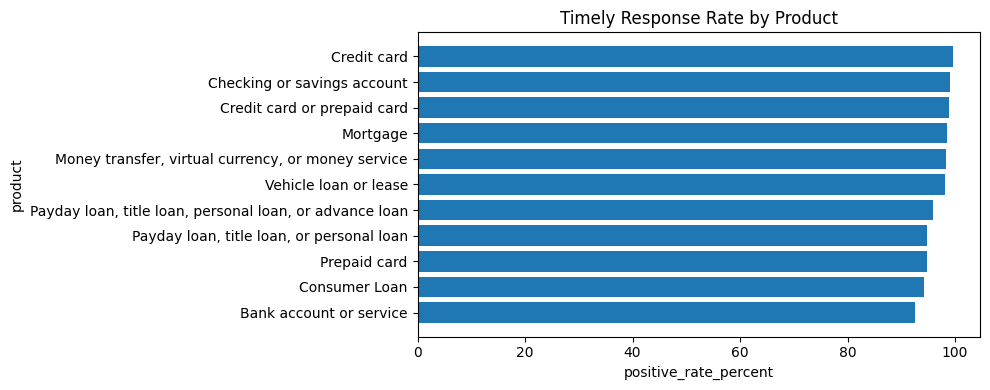

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_timely_response_rate_by_product_extended.png


In [36]:
# -------------------------------------------------------------------
# Timely-response rate by selected dimensions
# -------------------------------------------------------------------

timely_rate_dimensions = {
    "product": 500,
    "submitted_via": 500,
    "issue": 1000,
    "company": 5000,
    "state": 1000,
    "tags": 500,
}

timely_rate_tables = {}

for group_col, min_records in timely_rate_dimensions.items():
    if group_col in df.columns:
        table = grouped_binary_rate(
            df,
            group_col=group_col,
            target_col="timely_response_binary",
            min_records=min_records,
            top_n=30
        )

        timely_rate_tables[group_col] = table
        save_table(table, f"eda_timely_response_rate_by_{group_col}.csv")

        print(f"Timely-response rate by {group_col}")
        display(table.head(10))

# Plot selected useful views
if "submitted_via" in timely_rate_tables and len(timely_rate_tables["submitted_via"]) > 0:
    plot_horizontal_bar(
        timely_rate_tables["submitted_via"].sort_values("positive_rate_percent", ascending=True),
        label_col="submitted_via",
        value_col="positive_rate_percent",
        title="Timely Response Rate by Submission Channel",
        filename="eda_timely_response_rate_by_submitted_via.png"
    )

if "product" in timely_rate_tables and len(timely_rate_tables["product"]) > 0:
    plot_horizontal_bar(
        timely_rate_tables["product"].sort_values("positive_rate_percent", ascending=True),
        label_col="product",
        value_col="positive_rate_percent",
        title="Timely Response Rate by Product",
        filename="eda_timely_response_rate_by_product_extended.png"
    )


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_narrative_availability_rate_by_product.csv
Narrative availability rate by product


,product,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
5,"Money transfer, virtual currency, or money ser...",164638,112193,0.681453,68.15,53.28,14.87
10,"Payday loan, title loan, personal loan, or adv...",24745,14513,0.586502,58.65,53.28,5.37
11,Prepaid card,15540,9059,0.582947,58.29,53.28,5.01
9,"Payday loan, title loan, or personal loan",30622,17226,0.562537,56.25,53.28,2.97
12,Vehicle loan or lease,85430,47741,0.558832,55.88,53.28,2.60
4,Credit card or prepaid card,206357,108683,0.526675,52.67,53.28,-0.61
2,Consumer Loan,3543,1823,0.514536,51.45,53.28,-1.83
7,Mortgage,221283,111405,0.503450,50.35,53.28,-2.93
1,Checking or savings account,333982,168016,0.503069,50.31,53.28,-2.97
3,Credit card,194996,93023,0.477051,47.71,53.28,-5.57


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_narrative_availability_rate_by_submitted_via.csv
Narrative availability rate by submitted_via


,submitted_via,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
5,Web,1057743,686744,0.649254,64.93,53.28,11.65
4,Referral,115982,0,0.000000,0.00,53.28,-53.28
2,Phone,90440,0,0.000000,0.00,53.28,-53.28
3,Postal mail,21424,0,0.000000,0.00,53.28,-53.28
1,Fax,3406,0,0.000000,0.00,53.28,-53.28


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_narrative_availability_rate_by_issue.csv
Narrative availability rate by issue


,issue,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
83,Other transaction problem,67507,53405,0.791103,79.11,53.28,25.83
95,Problem with a credit reporting company's inve...,10734,7816,0.728154,72.82,53.28,19.54
126,Trouble accessing funds in your mobile or digi...,4844,3309,0.683113,68.31,53.28,15.03
134,Unexpected or other fees,6873,4523,0.658082,65.81,53.28,12.53
81,Other service problem,5049,3294,0.652406,65.24,53.28,11.96
91,Problem caused by your funds being low,26945,17409,0.646094,64.61,53.28,11.33
31,Confusing or misleading advertising or marketing,1115,719,0.644843,64.48,53.28,11.20
99,Problem with additional add-on products or ser...,2818,1812,0.643009,64.30,53.28,11.02
6,"Advertising and marketing, including promotion...",16331,10410,0.637438,63.74,53.28,10.46
32,Confusing or missing disclosures,4109,2589,0.630080,63.01,53.28,9.73


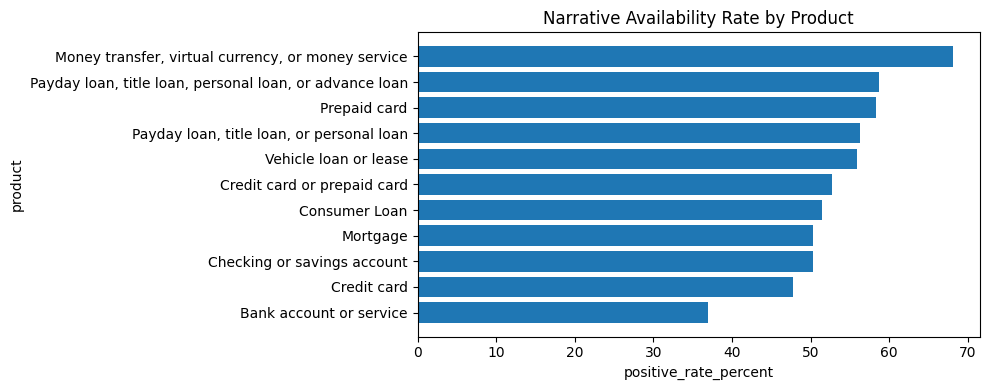

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_narrative_availability_rate_by_product.png


In [37]:
# -------------------------------------------------------------------
# Narrative availability by product, channel, and issue
# -------------------------------------------------------------------

narrative_dimensions = {
    "product": 500,
    "submitted_via": 500,
    "issue": 1000,
}

narrative_rate_tables = {}

for group_col, min_records in narrative_dimensions.items():
    if group_col in df.columns and "has_narrative" in df.columns:
        table = grouped_binary_rate(
            df,
            group_col=group_col,
            target_col="has_narrative",
            min_records=min_records,
            top_n=30
        )

        narrative_rate_tables[group_col] = table
        save_table(table, f"eda_narrative_availability_rate_by_{group_col}.csv")

        print(f"Narrative availability rate by {group_col}")
        display(table.head(10))

if "product" in narrative_rate_tables and len(narrative_rate_tables["product"]) > 0:
    plot_horizontal_bar(
        narrative_rate_tables["product"].sort_values("positive_rate_percent", ascending=True),
        label_col="product",
        value_col="positive_rate_percent",
        title="Narrative Availability Rate by Product",
        filename="eda_narrative_availability_rate_by_product.png"
    )


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_relief_response_counts.csv


,relief_response_binary,count,percent,label
0,0,1041323,80.78,Non-relief or other response
1,1,247704,19.22,Relief-based response


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_relief_response_rate_by_product.csv
Relief-response rate by product


,product,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
3,Credit card,194996,70089,0.359438,35.94,19.22,16.72
4,Credit card or prepaid card,206357,60519,0.293273,29.33,19.22,10.11
11,Prepaid card,15540,4448,0.286229,28.62,19.22,9.40
0,Bank account or service,6955,1898,0.272897,27.29,19.22,8.07
1,Checking or savings account,333982,68416,0.204849,20.48,19.22,1.26
2,Consumer Loan,3543,513,0.144793,14.48,19.22,-4.74
9,"Payday loan, title loan, or personal loan",30622,3068,0.100189,10.02,19.22,-9.20
12,Vehicle loan or lease,85430,8178,0.095727,9.57,19.22,-9.65
5,"Money transfer, virtual currency, or money ser...",164638,14727,0.089451,8.95,19.22,-10.27
10,"Payday loan, title loan, personal loan, or adv...",24745,1932,0.078076,7.81,19.22,-11.41


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_relief_response_rate_by_issue.csv
Relief-response rate by issue


,issue,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
94,Problem with a company's investigation into an...,26792,12399,0.462787,46.28,19.22,27.06
44,Fees or interest,36225,14293,0.394562,39.46,19.22,20.24
98,Problem with a purchase shown on your statement,90135,31060,0.344594,34.46,19.22,15.24
16,Billing disputes,1405,465,0.330961,33.10,19.22,13.88
128,Trouble using the card,12625,4035,0.319604,31.96,19.22,12.74
47,Getting a credit card,46847,14680,0.313361,31.34,19.22,12.12
54,Incorrect information on your report,52718,16401,0.311108,31.11,19.22,11.89
95,Problem with a credit reporting company's inve...,10734,3244,0.302217,30.22,19.22,11.00
6,"Advertising and marketing, including promotion...",16331,4776,0.292450,29.24,19.22,10.02
78,"Other features, terms, or problems",40355,11376,0.281898,28.19,19.22,8.97


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_relief_response_rate_by_submitted_via.csv
Relief-response rate by submitted_via


,submitted_via,total_records,positive_records,positive_rate,positive_rate_percent,overall_rate_percent,rate_difference_vs_overall_pp
4,Referral,115982,22958,0.197945,19.79,19.22,0.57
5,Web,1057743,205316,0.194108,19.41,19.22,0.19
2,Phone,90440,15669,0.173253,17.33,19.22,-1.89
3,Postal mail,21424,3287,0.153426,15.34,19.22,-3.88
1,Fax,3406,470,0.137992,13.80,19.22,-5.42


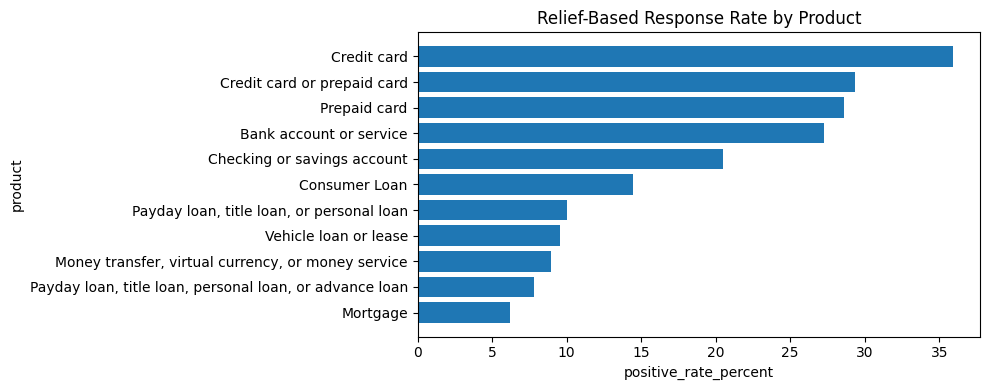

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_relief_response_rate_by_product.png


In [38]:
# -------------------------------------------------------------------
# Relief-based response analysis
# -------------------------------------------------------------------
# Relief-based outcomes include company response categories containing
# monetary relief or non-monetary relief.

if "company_response_to_consumer" in df.columns:
    df["relief_response_binary"] = (
        df["company_response_to_consumer"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains("monetary relief|non-monetary relief", regex=True)
        .astype(int)
    )

    relief_response_counts = count_percent_table(df, "relief_response_binary")
    relief_response_counts["label"] = relief_response_counts["relief_response_binary"].map({
        1: "Relief-based response",
        0: "Non-relief or other response"
    })
    save_table(relief_response_counts, "eda_relief_response_counts.csv")
    display(relief_response_counts)

    for group_col, min_records in {"product": 500, "issue": 1000, "submitted_via": 500}.items():
        if group_col in df.columns:
            table = grouped_binary_rate(
                df,
                group_col=group_col,
                target_col="relief_response_binary",
                min_records=min_records,
                top_n=30
            )

            save_table(table, f"eda_relief_response_rate_by_{group_col}.csv")
            print(f"Relief-response rate by {group_col}")
            display(table.head(10))

    if "product" in df.columns:
        relief_by_product = grouped_binary_rate(
            df,
            group_col="product",
            target_col="relief_response_binary",
            min_records=500,
            top_n=30
        )

        if len(relief_by_product) > 0:
            plot_horizontal_bar(
                relief_by_product.sort_values("positive_rate_percent", ascending=True),
                label_col="product",
                value_col="positive_rate_percent",
                title="Relief-Based Response Rate by Product",
                filename="eda_relief_response_rate_by_product.png"
            )
else:
    print("company_response_to_consumer not available.")


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_received_to_sent_lag_by_product.csv
Received-to-sent lag by product


,product,total_records,mean_value,median_value,p75_value,p90_value
2,Consumer Loan,3543,3.01,0.0,3.0,6.0
9,"Payday loan, title loan, or personal loan",30622,2.80,0.0,1.0,11.0
10,"Payday loan, title loan, personal loan, or adv...",24744,1.98,0.0,0.0,5.0
7,Mortgage,221281,1.92,0.0,0.0,5.0
11,Prepaid card,15537,1.71,0.0,0.0,4.0
0,Bank account or service,6955,1.69,0.0,2.0,5.0
4,Credit card or prepaid card,206357,1.54,0.0,0.0,3.0
12,Vehicle loan or lease,85428,1.43,0.0,0.0,2.0
1,Checking or savings account,333978,1.15,0.0,0.0,2.0
5,"Money transfer, virtual currency, or money ser...",164638,0.95,0.0,0.0,1.0


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_received_to_sent_lag_by_submitted_via.csv
Received-to-sent lag by submitted_via


,submitted_via,total_records,mean_value,median_value,p75_value,p90_value
4,Referral,115982,3.31,1.0,3.0,8.0
2,Phone,90435,2.44,0.0,0.0,8.0
1,Fax,3406,2.08,0.0,2.0,6.0
3,Postal mail,21423,1.84,0.0,0.0,5.0
5,Web,1057735,1.05,0.0,0.0,1.0


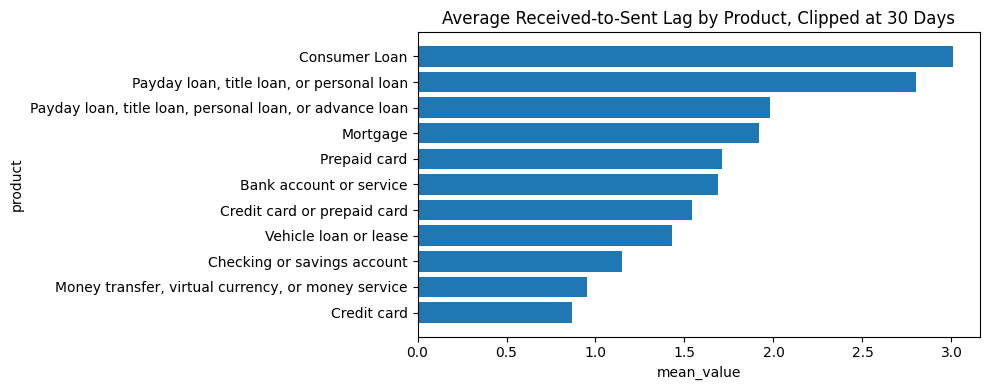

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_received_to_sent_lag_by_product.png


In [39]:
# -------------------------------------------------------------------
# Process lag by product and submission channel
# -------------------------------------------------------------------

if "received_to_sent_lag_days" in df.columns:
    # Limit extreme values for descriptive review
    df["received_to_sent_lag_days_clipped"] = df["received_to_sent_lag_days"].clip(lower=0, upper=30)

    for group_col, min_records in {"product": 500, "submitted_via": 500}.items():
        if group_col in df.columns:
            lag_table = grouped_numeric_summary(
                df,
                group_col=group_col,
                value_col="received_to_sent_lag_days_clipped",
                min_records=min_records,
                top_n=30
            )

            save_table(lag_table, f"eda_received_to_sent_lag_by_{group_col}.csv")
            print(f"Received-to-sent lag by {group_col}")
            display(lag_table.head(10))

    if "product" in df.columns:
        lag_by_product = grouped_numeric_summary(
            df,
            group_col="product",
            value_col="received_to_sent_lag_days_clipped",
            min_records=500,
            top_n=30
        )

        if len(lag_by_product) > 0:
            plot_horizontal_bar(
                lag_by_product.sort_values("mean_value", ascending=True),
                label_col="product",
                value_col="mean_value",
                title="Average Received-to-Sent Lag by Product, Clipped at 30 Days",
                filename="eda_received_to_sent_lag_by_product.png"
            )
else:
    print("received_to_sent_lag_days not available.")


## Step 20: Numeric Correlation Analysis

This section checks simple numeric correlations among engineered variables. Correlation is useful for identifying linear relationships and potential redundancy, but it does not prove causation.

Because several variables are binary indicators, correlations should be interpreted as association signals rather than causal effects.


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_numeric_correlation_matrix.csv


,year_received,timely_response_binary,has_narrative,narrative_length,received_to_sent_lag_days,received_to_sent_lag_days_clipped,relief_response_binary
year_received,1.0000,0.0275,0.1048,0.0041,-0.0310,-0.0506,0.0047
timely_response_binary,0.0275,1.0000,-0.0049,-0.0078,-0.0365,-0.0352,0.0252
has_narrative,0.1048,-0.0049,1.0000,0.5172,-0.0380,-0.0548,-0.0254
narrative_length,0.0041,-0.0078,0.5172,1.0000,-0.0134,-0.0210,-0.0044
received_to_sent_lag_days,-0.0310,-0.0365,-0.0380,-0.0134,1.0000,0.7905,-0.0241
received_to_sent_lag_days_clipped,-0.0506,-0.0352,-0.0548,-0.0210,0.7905,1.0000,-0.0300
relief_response_binary,0.0047,0.0252,-0.0254,-0.0044,-0.0241,-0.0300,1.0000


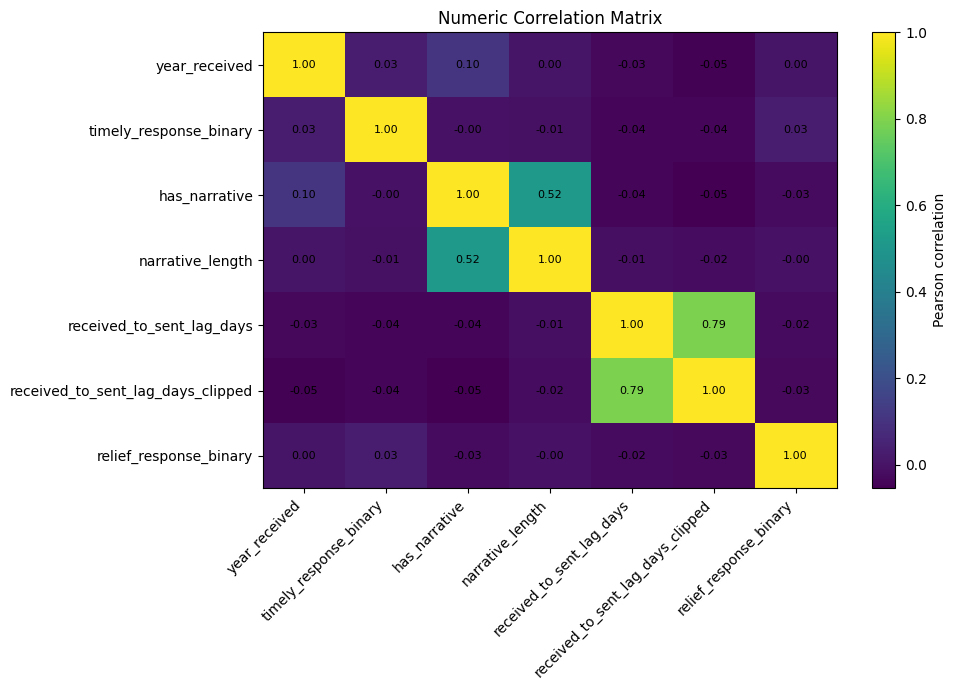

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_numeric_correlation_heatmap.png
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_numeric_correlation_pairs_ranked.csv


,field_1,field_2,correlation,absolute_correlation
28,received_to_sent_lag_days,received_to_sent_lag_days_clipped,0.7905,0.7905
20,narrative_length,has_narrative,0.5172,0.5172
1,year_received,has_narrative,0.1048,0.1048
32,received_to_sent_lag_days_clipped,has_narrative,-0.0548,0.0548
30,received_to_sent_lag_days_clipped,year_received,-0.0506,0.0506
15,has_narrative,received_to_sent_lag_days,-0.0380,0.0380
25,received_to_sent_lag_days,timely_response_binary,-0.0365,0.0365
10,timely_response_binary,received_to_sent_lag_days_clipped,-0.0352,0.0352
3,year_received,received_to_sent_lag_days,-0.0310,0.0310
41,relief_response_binary,received_to_sent_lag_days_clipped,-0.0300,0.0300


In [40]:
# -------------------------------------------------------------------
# Numeric correlation matrix
# -------------------------------------------------------------------

correlation_candidate_columns = [
    "year_received",
    "timely_response_binary",
    "has_narrative",
    "narrative_length",
    "received_to_sent_lag_days",
    "received_to_sent_lag_days_clipped",
    "relief_response_binary"
]

correlation_columns = [
    col for col in correlation_candidate_columns
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

if len(correlation_columns) >= 2:
    correlation_matrix = df[correlation_columns].corr(method="pearson").round(4)

    save_table(
        correlation_matrix.reset_index().rename(columns={"index": "field"}),
        "eda_numeric_correlation_matrix.csv"
    )

    display(correlation_matrix)

    plt.figure(figsize=(10, 7))
    matrix_values = correlation_matrix.fillna(0).values
    plt.imshow(matrix_values, aspect="auto")
    plt.colorbar(label="Pearson correlation")
    plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45, ha="right")
    plt.yticks(range(len(correlation_columns)), correlation_columns)

    for i in range(len(correlation_columns)):
        for j in range(len(correlation_columns)):
            plt.text(j, i, f"{matrix_values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.title("Numeric Correlation Matrix")
    plt.tight_layout()

    output_path = OUTPUT_FIGURES / "eda_numeric_correlation_heatmap.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", output_path)

    # Long-form table of strongest absolute correlations, excluding self-correlation
    correlation_long = (
        correlation_matrix
        .where(~np.eye(correlation_matrix.shape[0], dtype=bool))
        .stack()
        .reset_index()
    )
    correlation_long.columns = ["field_1", "field_2", "correlation"]
    correlation_long["absolute_correlation"] = correlation_long["correlation"].abs()
    correlation_long = correlation_long.sort_values("absolute_correlation", ascending=False)

    # Keep one copy of each pair
    correlation_long["pair_key"] = correlation_long.apply(
        lambda row: tuple(sorted([row["field_1"], row["field_2"]])),
        axis=1
    )
    correlation_long = correlation_long.drop_duplicates("pair_key").drop(columns=["pair_key"])

    save_table(correlation_long, "eda_numeric_correlation_pairs_ranked.csv")
    display(correlation_long.head(15))
else:
    print("Not enough numeric columns for correlation analysis.")


## Step 21: Categorical Dependency Checks

This section uses chi-square tests and Cramer's V to check dependency between categorical variables. The p-value shows whether an association is statistically detectable, while Cramer's V shows the practical strength of the relationship.

For high-cardinality columns such as company and issue, rare categories are collapsed into “Other” before testing to make the dependency checks stable and readable.


In [41]:
# -------------------------------------------------------------------
# Categorical dependency helper functions
# -------------------------------------------------------------------

from scipy.stats import chi2_contingency

def collapse_rare_categories(series, top_n=25, min_count=500):
    values = series.fillna("Missing").astype(str)
    counts = values.value_counts()

    keep_values = counts[counts >= min_count].head(top_n).index
    collapsed = values.where(values.isin(keep_values), other="Other")

    return collapsed


def cramers_v_from_crosstab(crosstab):
    if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
        return np.nan, np.nan, np.nan, np.nan

    chi2, p_value, dof, expected = chi2_contingency(crosstab, correction=False)

    n = crosstab.values.sum()
    if n <= 1:
        return chi2, p_value, dof, np.nan

    phi2 = chi2 / n
    r, k = crosstab.shape

    # Bias-corrected Cramer's V
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(k_corrected - 1, r_corrected - 1)

    if denominator <= 0:
        cramers_v = np.nan
    else:
        cramers_v = np.sqrt(phi2_corrected / denominator)

    return chi2, p_value, dof, cramers_v


def interpret_cramers_v(value):
    if pd.isna(value):
        return "Not available"
    if value < 0.10:
        return "Very weak"
    if value < 0.30:
        return "Weak"
    if value < 0.50:
        return "Moderate"
    return "Strong"


def dependency_test(dataframe, col_1, col_2, top_n=25, min_count=500):
    temp = dataframe[[col_1, col_2]].copy()

    x = collapse_rare_categories(temp[col_1], top_n=top_n, min_count=min_count)
    y = collapse_rare_categories(temp[col_2], top_n=top_n, min_count=min_count)

    crosstab = pd.crosstab(x, y)

    chi2, p_value, dof, cramers_v = cramers_v_from_crosstab(crosstab)

    return {
        "field_1": col_1,
        "field_2": col_2,
        "rows_after_collapse": int(crosstab.shape[0]),
        "columns_after_collapse": int(crosstab.shape[1]),
        "chi_square": round(chi2, 4) if not pd.isna(chi2) else np.nan,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "cramers_v": round(cramers_v, 4) if not pd.isna(cramers_v) else np.nan,
        "association_strength": interpret_cramers_v(cramers_v)
    }


In [42]:
# -------------------------------------------------------------------
# Dependency checks against key outcomes
# -------------------------------------------------------------------

outcome_dependency_pairs = []

candidate_predictors = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company",
    "state",
    "tags",
    "submitted_via",
    "has_narrative"
]

candidate_outcomes = [
    "timely_response",
    "company_response_to_consumer",
    "relief_response_binary"
]

available_predictors = [col for col in candidate_predictors if col in df.columns]
available_outcomes = [col for col in candidate_outcomes if col in df.columns]

for outcome_col in available_outcomes:
    for predictor_col in available_predictors:
        if predictor_col != outcome_col:
            outcome_dependency_pairs.append((predictor_col, outcome_col))

dependency_rows = []

for predictor_col, outcome_col in outcome_dependency_pairs:
    result = dependency_test(
        df,
        col_1=predictor_col,
        col_2=outcome_col,
        top_n=30,
        min_count=500
    )
    dependency_rows.append(result)

chi_square_dependency_summary = (
    pd.DataFrame(dependency_rows)
    .sort_values("cramers_v", ascending=False)
)

save_table(chi_square_dependency_summary, "eda_chi_square_dependency_summary.csv")
display(chi_square_dependency_summary)

# A focused list of the strongest practical associations
top_dependency_signals = chi_square_dependency_summary.head(20).copy()
save_table(top_dependency_signals, "eda_top_dependency_signals.csv")
display(top_dependency_signals)


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_chi_square_dependency_summary.csv


,field_1,field_2,rows_after_collapse,columns_after_collapse,chi_square,p_value,degrees_of_freedom,cramers_v,association_strength
22,company,relief_response_binary,31,2,189581.8826,0.000000e+00,30,0.3835,Moderate
19,sub_product,relief_response_binary,31,2,95742.5080,0.000000e+00,30,0.2725,Weak
21,sub_issue,relief_response_binary,31,2,94827.3913,0.000000e+00,30,0.2712,Weak
18,product,relief_response_binary,12,2,94417.0836,0.000000e+00,11,0.2706,Weak
20,issue,relief_response_binary,31,2,93906.8402,0.000000e+00,30,0.2699,Weak
13,company,company_response_to_consumer,31,5,364542.9581,0.000000e+00,120,0.2659,Weak
12,sub_issue,company_response_to_consumer,31,5,241802.8043,0.000000e+00,120,0.2165,Weak
11,issue,company_response_to_consumer,31,5,238152.3503,0.000000e+00,120,0.2149,Weak
9,product,company_response_to_consumer,12,5,140905.2240,0.000000e+00,44,0.1653,Weak
10,sub_product,company_response_to_consumer,31,5,136421.7200,0.000000e+00,120,0.1626,Weak


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_top_dependency_signals.csv


,field_1,field_2,rows_after_collapse,columns_after_collapse,chi_square,p_value,degrees_of_freedom,cramers_v,association_strength
22,company,relief_response_binary,31,2,189581.8826,0.000000e+00,30,0.3835,Moderate
19,sub_product,relief_response_binary,31,2,95742.5080,0.000000e+00,30,0.2725,Weak
21,sub_issue,relief_response_binary,31,2,94827.3913,0.000000e+00,30,0.2712,Weak
18,product,relief_response_binary,12,2,94417.0836,0.000000e+00,11,0.2706,Weak
20,issue,relief_response_binary,31,2,93906.8402,0.000000e+00,30,0.2699,Weak
13,company,company_response_to_consumer,31,5,364542.9581,0.000000e+00,120,0.2659,Weak
12,sub_issue,company_response_to_consumer,31,5,241802.8043,0.000000e+00,120,0.2165,Weak
11,issue,company_response_to_consumer,31,5,238152.3503,0.000000e+00,120,0.2149,Weak
9,product,company_response_to_consumer,12,5,140905.2240,0.000000e+00,44,0.1653,Weak
10,sub_product,company_response_to_consumer,31,5,136421.7200,0.000000e+00,120,0.1626,Weak


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_categorical_dependency_cramers_v_matrix.csv


,product,issue,company,state,submitted_via,tags,timely_response,company_response_to_consumer,has_narrative,relief_response_binary
product,1.0000,0.5836,0.3358,0.0505,0.1027,0.0677,0.0925,0.1653,0.1263,0.2706
issue,0.5836,1.0000,0.2572,0.0420,0.1063,0.0911,0.0833,0.2093,0.1847,0.2637
company,0.3358,0.2572,1.0000,0.0735,0.0859,0.1109,0.1126,0.2636,0.1675,0.3799
state,0.0505,0.0420,0.0735,1.0000,0.0979,0.0646,0.0195,0.0376,0.1006,0.0463
submitted_via,0.1027,0.1063,0.0859,0.0979,1.0000,0.1113,0.0104,0.0308,0.4993,0.0202
tags,0.0677,0.0911,0.1109,0.0646,0.1113,1.0000,0.0000,0.0269,0.0851,0.0273
timely_response,0.0925,0.0833,0.1126,0.0195,0.0104,0.0000,1.0000,0.3656,0.0048,0.0252
company_response_to_consumer,0.1653,0.2093,0.2636,0.0376,0.0308,0.0269,0.3656,1.0000,0.0438,1.0000
has_narrative,0.1263,0.1847,0.1675,0.1006,0.4993,0.0851,0.0048,0.0438,1.0000,0.0254
relief_response_binary,0.2706,0.2637,0.3799,0.0463,0.0202,0.0273,0.0252,1.0000,0.0254,1.0000


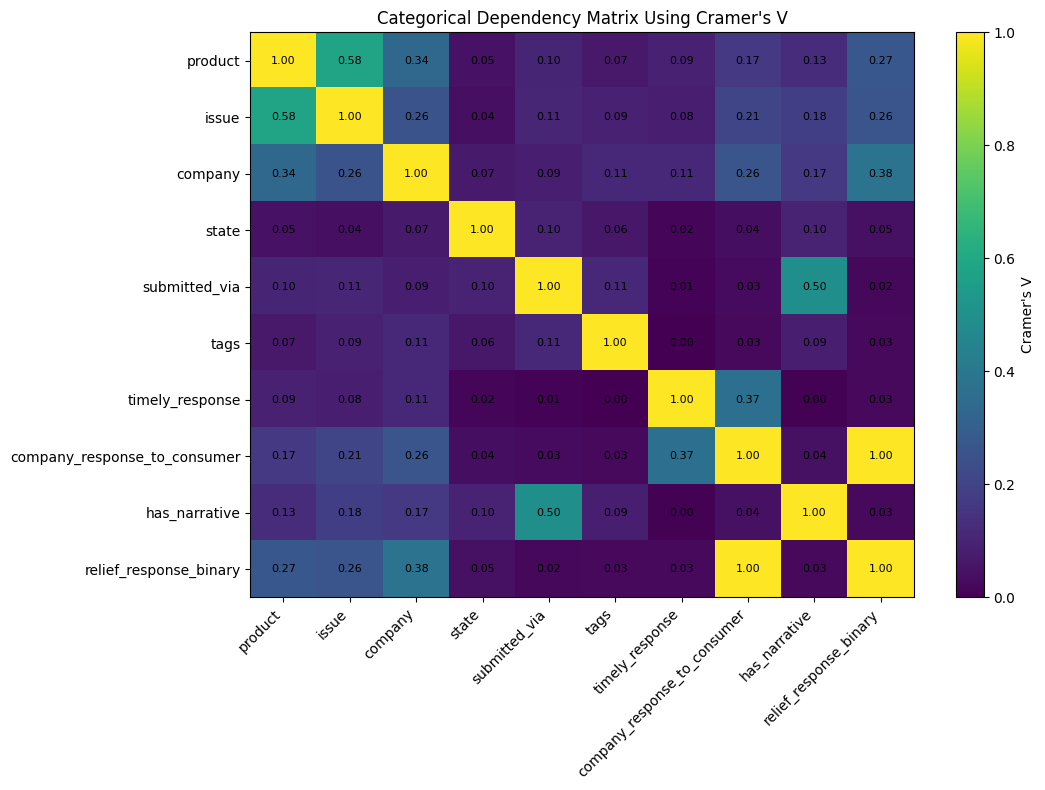

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/eda_categorical_dependency_cramers_v_heatmap.png


In [43]:
# -------------------------------------------------------------------
# Cramer's V matrix for selected categorical variables
# -------------------------------------------------------------------

dependency_matrix_columns = [
    "product",
    "issue",
    "company",
    "state",
    "submitted_via",
    "tags",
    "timely_response",
    "company_response_to_consumer",
    "has_narrative",
    "relief_response_binary"
]

dependency_matrix_columns = [col for col in dependency_matrix_columns if col in df.columns]

if len(dependency_matrix_columns) >= 2:
    matrix = pd.DataFrame(
        np.eye(len(dependency_matrix_columns)),
        index=dependency_matrix_columns,
        columns=dependency_matrix_columns
    )

    for i, col_1 in enumerate(dependency_matrix_columns):
        for j, col_2 in enumerate(dependency_matrix_columns):
            if i < j:
                result = dependency_test(
                    df,
                    col_1=col_1,
                    col_2=col_2,
                    top_n=25,
                    min_count=500
                )
                matrix.loc[col_1, col_2] = result["cramers_v"]
                matrix.loc[col_2, col_1] = result["cramers_v"]

    matrix = matrix.round(4)

    save_table(
        matrix.reset_index().rename(columns={"index": "field"}),
        "eda_categorical_dependency_cramers_v_matrix.csv"
    )

    display(matrix)

    plt.figure(figsize=(11, 8))
    matrix_values = matrix.fillna(0).values
    plt.imshow(matrix_values, aspect="auto")
    plt.colorbar(label="Cramer's V")
    plt.xticks(range(len(dependency_matrix_columns)), dependency_matrix_columns, rotation=45, ha="right")
    plt.yticks(range(len(dependency_matrix_columns)), dependency_matrix_columns)

    for i in range(len(dependency_matrix_columns)):
        for j in range(len(dependency_matrix_columns)):
            plt.text(j, i, f"{matrix_values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.title("Categorical Dependency Matrix Using Cramer's V")
    plt.tight_layout()

    output_path = OUTPUT_FIGURES / "eda_categorical_dependency_cramers_v_heatmap.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", output_path)
else:
    print("Not enough categorical variables for dependency matrix.")


## Step 22: Dependency Interpretation Notes

These checks help prepare for hypothesis testing and modeling. They do not prove causality. They identify where variables move together and where the model may find useful predictive signal.

Important interpretation rules:

- A very small p-value is expected in large datasets, so Cramer's V should be reviewed for practical strength.
- High dependency between predictors may indicate redundancy.
- High dependency with outcomes may indicate useful predictive signal.
- Company and geography results must be interpreted carefully because the CFPB data does not include company size, customer base, or market share.
- Narrative-related findings apply only to complaints where consumers consented to publication of the narrative.


## Step 23: Summary of EDA Observations

This section creates a short machine-readable summary of key observations. You can use these notes later in the final report.


In [44]:
# -------------------------------------------------------------------
# EDA observations summary
# -------------------------------------------------------------------
observations = []

observations.append({
    "area": "Dataset size",
    "observation": f"The processed dataset contains {df.shape[0]:,} rows and {df.shape[1]:,} columns."
})

if "date_received" in df.columns:
    observations.append({
        "area": "Date coverage",
        "observation": f"The dataset covers complaints from {df['date_received'].min()} to {df['date_received'].max()}."
    })

if "product" in df.columns:
    top_product = product_counts.iloc[0]["product"]
    top_product_share = product_counts.iloc[0]["percent"]
    observations.append({
        "area": "Product concentration",
        "observation": f"The largest product category is '{top_product}', representing {top_product_share}% of filtered records."
    })

if "issue" in df.columns:
    top_issue = issue_counts.iloc[0]["issue"]
    top_issue_share = issue_counts.iloc[0]["percent"]
    observations.append({
        "area": "Issue concentration",
        "observation": f"The largest issue category is '{top_issue}', representing {top_issue_share}% of filtered records."
    })

if "timely_response" in df.columns:
    top_timely = timely_response_counts.iloc[0]["timely_response"]
    top_timely_share = timely_response_counts.iloc[0]["percent"]
    observations.append({
        "area": "Target balance: timely response",
        "observation": f"The most common timely-response class is '{top_timely}', representing {top_timely_share}% of records."
    })

if "company_response_to_consumer" in df.columns:
    top_response = company_response_counts.iloc[0]["company_response_to_consumer"]
    top_response_share = company_response_counts.iloc[0]["percent"]
    observations.append({
        "area": "Target balance: company response",
        "observation": f"The most common company response is '{top_response}', representing {top_response_share}% of records."
    })

if "has_narrative" in df.columns:
    observations.append({
        "area": "Narrative availability",
        "observation": f"{safe_rate(int(df['has_narrative'].sum()), len(df))}% of records have a published complaint narrative."
    })

observations_df = pd.DataFrame(observations)
save_table(observations_df, "eda_observations_summary.csv")

observations_df

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/eda_observations_summary.csv


,area,observation
0,Dataset size,"The processed dataset contains 1,289,027 rows ..."
1,Date coverage,The dataset covers complaints from 2017-01-01 ...
2,Product concentration,The largest product category is 'Checking or s...
3,Issue concentration,The largest issue category is 'Managing an acc...
4,Target balance: timely response,The most common timely-response class is 'Yes'...
5,Target balance: company response,The most common company response is 'Closed wi...
6,Narrative availability,53.28% of records have a published complaint n...


## Step 24: Final File Checklist

This checklist confirms that the main EDA tables and charts were created.


In [45]:
# -------------------------------------------------------------------
# Final output checklist
# -------------------------------------------------------------------
expected_outputs = [
    OUTPUT_TABLES / "eda_dataset_overview.csv",
    OUTPUT_TABLES / "eda_column_summary.csv",
    OUTPUT_TABLES / "eda_product_counts.csv",
    OUTPUT_TABLES / "eda_issue_counts.csv",
    OUTPUT_TABLES / "eda_submitted_via_counts.csv",
    OUTPUT_TABLES / "eda_timely_response_counts.csv",
    OUTPUT_TABLES / "eda_company_response_counts.csv",
    OUTPUT_TABLES / "eda_narrative_availability_counts.csv",
    OUTPUT_TABLES / "eda_yearly_complaint_counts.csv",
    OUTPUT_TABLES / "eda_company_counts.csv",
    OUTPUT_TABLES / "eda_state_counts.csv",
    OUTPUT_TABLES / "eda_observations_summary.csv",
    OUTPUT_FIGURES / "eda_product_counts.png",
    OUTPUT_FIGURES / "eda_top_20_issues.png",
    OUTPUT_FIGURES / "eda_timely_response_distribution.png",
    OUTPUT_FIGURES / "eda_company_response_distribution.png",
    OUTPUT_FIGURES / "eda_complaint_count_by_year.png",

    # Extended univariate, bivariate, correlation, and dependency outputs
    OUTPUT_TABLES / "eda_numeric_univariate_summary.csv",
    OUTPUT_TABLES / "eda_categorical_concentration_summary.csv",
    OUTPUT_TABLES / "eda_timely_response_rate_by_product.csv",
    OUTPUT_TABLES / "eda_timely_response_rate_by_submitted_via.csv",
    OUTPUT_TABLES / "eda_narrative_availability_rate_by_product.csv",
    OUTPUT_TABLES / "eda_relief_response_counts.csv",
    OUTPUT_TABLES / "eda_numeric_correlation_matrix.csv",
    OUTPUT_TABLES / "eda_numeric_correlation_pairs_ranked.csv",
    OUTPUT_TABLES / "eda_chi_square_dependency_summary.csv",
    OUTPUT_TABLES / "eda_categorical_dependency_cramers_v_matrix.csv",
    OUTPUT_FIGURES / "eda_numeric_correlation_heatmap.png",
    OUTPUT_FIGURES / "eda_categorical_dependency_cramers_v_heatmap.png",
]

checklist = pd.DataFrame([
    {
        "file": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024**2), 4) if path.exists() else None
    }
    for path in expected_outputs
])

checklist


,file,exists,size_mb
0,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0003
1,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0009
2,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0005
3,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0055
4,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
5,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
6,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0002
7,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
8,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0002
9,/content/drive/MyDrive/retail-complaint-resolu...,True,0.1473


## Next Step

After completing this notebook, continue with:

`03_hypothesis_tests.ipynb`

That notebook will formally test the research questions using statistical tests such as chi-square tests and logistic regression.